<a href="https://colab.research.google.com/github/hoailinh07102005-dev/Game-caro/blob/main/Project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1.Load data

In [ ]:
#import 1 sô thư viện có sẵn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.set_option('display.max_colwidth',None)
pd.set_option('display.max_columns',None)



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df_customer=pd.read_csv('/content/drive/MyDrive/Dataset/movie_ticket_data/customer.csv')
df_campaign=pd.read_csv('/content/drive/MyDrive/Dataset/movie_ticket_data/campaign.csv')
df_device=pd.read_csv('/content/drive/MyDrive/Dataset/movie_ticket_data/device_detail.csv')

df_status=pd.read_csv('/content/drive/MyDrive/Dataset/movie_ticket_data/status_detail.csv')
df_ticket=pd.read_csv('/content/drive/MyDrive/Dataset/movie_ticket_data/ticket_history.csv')

In [ ]:
df_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131400 entries, 0 to 131399
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   customer_id  131400 non-null  int64 
 1   usergender   131400 non-null  object
 2   dob          131400 non-null  object
dtypes: int64(1), object(2)
memory usage: 3.0+ MB


In [ ]:
df_customer.head()


,customer_id,usergender,dob
0,100032,Female,8/8/1985
1,100046,Male,7/11/1987
2,100050,Male,11/19/1994
3,100063,Male,9/10/1999
4,100076,Female,5/14/1995


# 2.Data cleaning

## 2.1 data type, null values , duplicate value



In [ ]:
df_customer.info()# Bang customer

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131400 entries, 0 to 131399
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   customer_id  131400 non-null  int64 
 1   usergender   131400 non-null  object
 2   dob          131400 non-null  object
dtypes: int64(1), object(2)
memory usage: 3.0+ MB


In [ ]:
df_customer.head()

,customer_id,usergender,dob
0,100032,Female,8/8/1985
1,100046,Male,7/11/1987
2,100050,Male,11/19/1994
3,100063,Male,9/10/1999
4,100076,Female,5/14/1995


In [ ]:
# Chuyển đồi kiểu dữ liệu của dob thành  datetime
from datetime import datetime
df_customer['dob'] = pd.to_datetime(df_customer['dob'])


In [ ]:
df_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131400 entries, 0 to 131399
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   customer_id  131400 non-null  int64         
 1   usergender   131400 non-null  object        
 2   dob          131400 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 3.0+ MB


In [ ]:
df_customer.duplicated().sum()

np.int64(0)

In [ ]:
df_customer['customer_id'].nunique()

131400

In [ ]:
# Bang campaign

In [ ]:
df_campaign.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216 entries, 0 to 215
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   campaign_id    216 non-null    int64 
 1   campaign_type  216 non-null    object
dtypes: int64(1), object(1)
memory usage: 3.5+ KB


In [ ]:
df_campaign.isnull().sum()

,0
campaign_id,0
campaign_type,0


In [ ]:
df_campaign.head()

,campaign_id,campaign_type
0,106460,direct discount
1,30040,direct discount
2,13810,voucher
3,78370,voucher
4,83700,voucher


In [ ]:
df_campaign['campaign_id'].nunique()

216

In [ ]:
# Bang device

In [ ]:
df_device.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139902 entries, 0 to 139901
Data columns (total 3 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   device_number  139901 non-null  object
 1   model          132763 non-null  object
 2   platform       139902 non-null  object
dtypes: object(3)
memory usage: 3.2+ MB


In [ ]:
df_device.head()

,device_number,model,platform
0,00006afbe30ae7018c92bb324cd58afc,browser,website
1,0000b0ce524ef4d66c7bfdad67a91970,devicemodel,mobile
2,0000e2a055b67fe49c06bbe28b268251,"iPhone10,2",mobile
3,00012f7a6842cca5d531b7c8b32967d6,"iPhone10,3",mobile
4,000215f1b9363b5465b8ee895fa6c920,devicemodel,mobile


In [ ]:
#create a funtion calculate Null rate of each columnd
def calc_null_rate(df):
    newdf = df.isnull().sum().to_frame('null_count')
    newdf[['null_rate']] = newdf[['null_count']] / len(df)
    return newdf.sort_values(by=['null_rate'], ascending=False)

In [ ]:
calc_null_rate(df_device)

,null_count,null_rate
model,7139,0.051029
device_number,1,0.000007
platform,0,0.000000


In [ ]:
#Thay the null trong cột model là unknow
# xoá giá trị null tron cột device_number
df_device=df_device.fillna({'model':'unknow'})
df_device=df_device[df_device['device_number'].notna()]

In [ ]:
calc_null_rate(df_device)

,null_count,null_rate
device_number,0,0.0
model,0,0.0
platform,0,0.0


In [ ]:
# Bảng status
df_status.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   status_id    8 non-null      int64 
 1   description  8 non-null      object
 2   error_group  7 non-null      object
dtypes: int64(1), object(2)
memory usage: 324.0+ bytes


In [ ]:
df_status.head()

,status_id,description,error_group
0,1,Order successful,NaN
1,-1,Payment overdue,customer
2,-2,Insufficient funds in customer account. Please add more funds and try the transaction again.,customer
3,-3,No response from your bank,external
4,-4,Password locked due to multiple incorrect attempts. Choose Forgot Password to unlock.,customer


In [ ]:
# Bảng ticket
df_ticket.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 154827 entries, 0 to 154826
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   ticket_id       154827 non-null  object 
 1   customer_id     154827 non-null  int64  
 2   paying_method   154827 non-null  object 
 3   theater_name    154827 non-null  float64
 4   device_number   154827 non-null  object 
 5   original_price  154827 non-null  float64
 6   discount_value  154827 non-null  float64
 7   final_price     154827 non-null  float64
 8   time            154827 non-null  object 
 9   status_id       154827 non-null  int64  
 10  campaign_id     154827 non-null  int64  
 11  movie_name      154827 non-null  object 
dtypes: float64(4), int64(3), object(5)
memory usage: 14.2+ MB


In [ ]:
df_ticket.duplicated().sum()

np.int64(102)

In [ ]:
df_ticket['ticket_id'].nunique()

154725

In [ ]:
df_ticket.head()

,ticket_id,customer_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,campaign_id,movie_name
0,4f5200dcdcf2396b8d50ff84bf423f32,100009,money in app,13.0,244764a57dbdeb8fe9b164847ad55183,9.90,2.10,7.80,2022-07-08 17:46:36.145,1,83330,Thor: Love And Thunder
1,07abbaf28c772692f0367ad992bb3184,100493,bank account,180.0,8fa83cf46284aafd6e5da6c96f7862b5,8.66,1.48,7.18,2022-07-15 20:44:09.952,1,83330,Thor: Love And Thunder
2,1fdbeb7eceba8a27d9d985b5b70c219a,100596,money in app,56.0,69cf9244654949047f006e441fa7a8a7,10.31,2.31,8.00,2022-07-30 11:16:55.483,1,0,Thor: Love And Thunder
3,7715c9955866bd296b98543412839abd,100852,bank account,119.0,879ed11af9d6d2b5cda4d299590735a7,27.75,1.03,26.72,2022-07-04 22:33:07.458,1,85940,Thor: Love And Thunder
4,776efd7bda0b715084430e6385f67746,100965,money in app,107.0,0a233600d993a02cc1d39fb0d87fc7de,4.33,1.03,3.30,2022-07-03 18:41:45.098,1,85940,Thor: Love And Thunder


In [ ]:
# Thay đổi kiểu dữ liệu cho cột time từ object sang datetime
df_ticket['time']=pd.to_datetime(df_ticket['time'])

In [ ]:
df_ticket.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 154827 entries, 0 to 154826
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   ticket_id       154827 non-null  object        
 1   customer_id     154827 non-null  int64         
 2   paying_method   154827 non-null  object        
 3   theater_name    154827 non-null  float64       
 4   device_number   154827 non-null  object        
 5   original_price  154827 non-null  float64       
 6   discount_value  154827 non-null  float64       
 7   final_price     154827 non-null  float64       
 8   time            154827 non-null  datetime64[ns]
 9   status_id       154827 non-null  int64         
 10  campaign_id     154827 non-null  int64         
 11  movie_name      154827 non-null  object        
dtypes: datetime64[ns](1), float64(4), int64(3), object(4)
memory usage: 14.2+ MB


In [ ]:
calc_null_rate(df_ticket)

,null_count,null_rate
ticket_id,0,0.0
customer_id,0,0.0
paying_method,0,0.0
theater_name,0,0.0
device_number,0,0.0
original_price,0,0.0
discount_value,0,0.0
final_price,0,0.0
time,0,0.0
status_id,0,0.0


In [ ]:
# kiểm tra xem có bị trùng lặp hay không

In [ ]:
df_ticket['ticket_id'].nunique()

154725

In [ ]:
154827-154725

102

In [ ]:
df_drop=df_ticket[df_ticket.duplicated (keep=False)]

In [ ]:
df_ticket.drop_duplicates(inplace=True)

In [ ]:
df_ticket.duplicated().sum()

np.int64(0)

In [ ]:
df_ticket.info()

<class 'pandas.core.frame.DataFrame'>
Index: 154725 entries, 0 to 154826
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   ticket_id       154725 non-null  object        
 1   customer_id     154725 non-null  int64         
 2   paying_method   154725 non-null  object        
 3   theater_name    154725 non-null  float64       
 4   device_number   154725 non-null  object        
 5   original_price  154725 non-null  float64       
 6   discount_value  154725 non-null  float64       
 7   final_price     154725 non-null  float64       
 8   time            154725 non-null  datetime64[ns]
 9   status_id       154725 non-null  int64         
 10  campaign_id     154725 non-null  int64         
 11  movie_name      154725 non-null  object        
dtypes: datetime64[ns](1), float64(4), int64(3), object(4)
memory usage: 15.3+ MB


In [ ]:
# Join tất cả các bảng này lại

## 2.2 Join table

In [ ]:
# Xuất phát từ bảng ticket để join với các bảng demsion còn lại
df_join_customer=pd.merge(df_ticket,df_customer,on='customer_id',how='left')
df_join_campaign=pd.merge(df_join_customer,df_campaign,how='left',on='campaign_id')
df_join_status=pd.merge(df_join_campaign,df_status,how='left',on='status_id')
df_join_all=pd.merge(df_join_status,df_device,how='left',on='device_number')

In [ ]:
df_join_all.count()

,0
ticket_id,154725
customer_id,154725
paying_method,154725
theater_name,154725
device_number,154725
original_price,154725
discount_value,154725
final_price,154725
time,154725
status_id,154725


In [ ]:
df_join_all.head()

,ticket_id,customer_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,campaign_id,movie_name,usergender,dob,campaign_type,description,error_group,model,platform
0,4f5200dcdcf2396b8d50ff84bf423f32,100009,money in app,13.0,244764a57dbdeb8fe9b164847ad55183,9.90,2.10,7.80,2022-07-08 17:46:36.145,1,83330,Thor: Love And Thunder,Male,1989-02-25,direct discount,Order successful,NaN,"iPhone13,1",mobile
1,07abbaf28c772692f0367ad992bb3184,100493,bank account,180.0,8fa83cf46284aafd6e5da6c96f7862b5,8.66,1.48,7.18,2022-07-15 20:44:09.952,1,83330,Thor: Love And Thunder,Male,1991-06-09,direct discount,Order successful,NaN,browser,website
2,1fdbeb7eceba8a27d9d985b5b70c219a,100596,money in app,56.0,69cf9244654949047f006e441fa7a8a7,10.31,2.31,8.00,2022-07-30 11:16:55.483,1,0,Thor: Love And Thunder,Male,1989-05-18,NaN,Order successful,NaN,unknow,mobile
3,7715c9955866bd296b98543412839abd,100852,bank account,119.0,879ed11af9d6d2b5cda4d299590735a7,27.75,1.03,26.72,2022-07-04 22:33:07.458,1,85940,Thor: Love And Thunder,Male,1997-08-31,direct discount,Order successful,NaN,devicemodel,mobile
4,776efd7bda0b715084430e6385f67746,100965,money in app,107.0,0a233600d993a02cc1d39fb0d87fc7de,4.33,1.03,3.30,2022-07-03 18:41:45.098,1,85940,Thor: Love And Thunder,Male,1988-09-20,direct discount,Order successful,NaN,devicemodel,mobile


In [ ]:
calc_null_rate(df_join_all)

,null_count,null_rate
error_group,133679,0.863978
campaign_type,63098,0.407807
platform,78,0.000504
model,78,0.000504
paying_method,0,0.000000
ticket_id,0,0.000000
customer_id,0,0.000000
theater_name,0,0.000000
device_number,0,0.000000
original_price,0,0.000000


In [ ]:
df_join_all=df_join_all.fillna('unknow')

In [ ]:
calc_null_rate(df_join_all)

,null_count,null_rate
ticket_id,0,0.0
customer_id,0,0.0
paying_method,0,0.0
theater_name,0,0.0
device_number,0,0.0
original_price,0,0.0
discount_value,0,0.0
final_price,0,0.0
time,0,0.0
status_id,0,0.0


## 2.3 View all values of each columns

In [ ]:
df_join_all.nunique().sort_values(ascending=False)

,0
ticket_id,154725
time,154725
device_number,126459
customer_id,119477
dob,11322
final_price,2715
original_price,1895
model,1215
movie_name,253
discount_value,242


In [ ]:
specific_cols = [
    'movie_name',
    'description',
    'paying_method',
    'campaign_type',
    'usergender',
    'platform',
    'error_group',
    'model'
    ]
for col in specific_cols:
    print(col + ' : ', np.sort(df_join_all[col].unique().astype(str)))
    print('\r')
    print('--------------------------')
    print('\r')

movie_name :  ['13rd Sister' '13rd Sister: Three Deadly Days' '1990' '2037'
 '30 Chua Phai Tet' '47 Meters Down: Uncaged' 'A Chamada Da Selva'
 'A Diamond In The Rough' 'Accidentally Dad' 'Aladdin' 'Alienoid'
 'Alita: Battle Angel' 'Ambulance' 'Anchor' 'Angel Has Fallen' 'Anna'
 'Annabelle Comes Home' 'Aquaman' 'Around The World In 80 Days'
 'Autumn Promise' 'Avatar' 'Avatar: The Way Of Water' 'Avengers: Endgame'
 'Bad Boys For Life' 'Batman' 'Beast' 'Birds Of Prey' 'Black Adam'
 'Black Panther 2: Wakanda Forever' 'Black Panther: Wakanda Forever'
 'Blood Karma' 'Blood Moon Party' 'Bloodshot' 'Broker' 'Bullet Train'
 'Bumblebee' 'Bắc Kim Thang' 'Camellia Sisters' 'Captain Marvel'
 "Charlie's Angels" 'Cherry Magic The Movie Thirty Years'
 'Chickenhare And The Hamster Of Darkness' 'Chuyện Ma Đô Thị' 'Collectors'
 'Concessions' 'Confidential Assignment 2: International' 'Cracked'
 'Crawl' 'Crazy Romance' "Dad I'm Sorry" 'Daddy Issues' 'Daeng'
 'Dark Figure Of Crime' 'Dc League Of Super-Pet

# 3.Analyze


## 3.1 Customer portrait

### Age and gender distribution

In [ ]:
df_join_all.head()

,ticket_id,customer_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,campaign_id,movie_name,usergender,dob,campaign_type,description,error_group,model,platform
0,4f5200dcdcf2396b8d50ff84bf423f32,100009,money in app,13.0,244764a57dbdeb8fe9b164847ad55183,9.90,2.10,7.80,2022-07-08 17:46:36.145,1,83330,Thor: Love And Thunder,Male,1989-02-25,direct discount,Order successful,unknow,"iPhone13,1",mobile
1,07abbaf28c772692f0367ad992bb3184,100493,bank account,180.0,8fa83cf46284aafd6e5da6c96f7862b5,8.66,1.48,7.18,2022-07-15 20:44:09.952,1,83330,Thor: Love And Thunder,Male,1991-06-09,direct discount,Order successful,unknow,browser,website
2,1fdbeb7eceba8a27d9d985b5b70c219a,100596,money in app,56.0,69cf9244654949047f006e441fa7a8a7,10.31,2.31,8.00,2022-07-30 11:16:55.483,1,0,Thor: Love And Thunder,Male,1989-05-18,unknow,Order successful,unknow,unknow,mobile
3,7715c9955866bd296b98543412839abd,100852,bank account,119.0,879ed11af9d6d2b5cda4d299590735a7,27.75,1.03,26.72,2022-07-04 22:33:07.458,1,85940,Thor: Love And Thunder,Male,1997-08-31,direct discount,Order successful,unknow,devicemodel,mobile
4,776efd7bda0b715084430e6385f67746,100965,money in app,107.0,0a233600d993a02cc1d39fb0d87fc7de,4.33,1.03,3.30,2022-07-03 18:41:45.098,1,85940,Thor: Love And Thunder,Male,1988-09-20,direct discount,Order successful,unknow,devicemodel,mobile


In [ ]:
# Tính số tuổi
current_date=datetime.now()

df_join_all['age_days']=(current_date-df_join_all['dob']).dt.days# Tinh số ngày tuổi
df_join_all['age']=df_join_all['age_days']/365.25# vì có cả năm nhuận
df_join_all['age']=df_join_all['age'].astype(int)





In [ ]:
current_date

datetime.datetime(2026, 9, 5, 1, 31, 59, 280862)

In [ ]:
# Lấy ra danh sách khahcs hàng kèm theo age và gender

In [ ]:
df_cus=df_join_all.drop_duplicates(subset=['customer_id'])[['customer_id','age','dob','usergender',]]

In [ ]:
df_cus

,customer_id,age,dob,usergender
0,100009,37,1989-02-25,Male
1,100493,35,1991-06-09,Male
2,100596,37,1989-05-18,Male
3,100852,29,1997-08-31,Male
4,100965,37,1988-09-20,Male
...,...,...,...,...
154720,194726,25,2001-01-21,Male
154721,211166,31,1995-05-05,Male
154722,211671,46,1980-05-19,Male
154723,223500,56,1970-01-01,Not verify


Text(0.5, 1.0, 'Phân bố theo tuổi ')

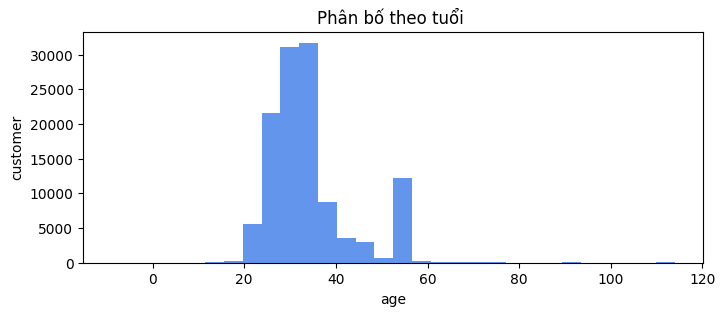

In [ ]:
# Phân bổ khách hàng theo độ tuổi
plt.figure(figsize=(8,3))
df_cus['age'].hist(bins=30,color='cornflowerblue',grid=False)
plt.xlabel('age')
plt.ylabel('customer')
plt.title('Phân bố theo tuổi ')





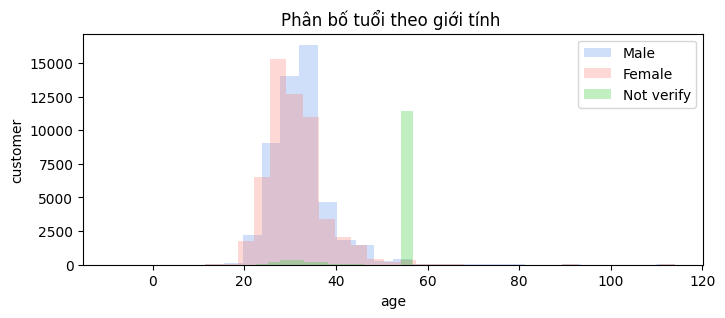

In [ ]:
# Phân bổ độ tuổi theo nhóm giới tính
plt.figure(figsize=(8,3))
##data
male_age=df_cus[df_cus['usergender']=='Male']['age']# chỉ lọc những dòng male trong cột ugender , thì trong df_cus chỉ lấy cột age
female_age=df_cus[df_cus['usergender']=='Female']['age']
unknown_age=df_cus[df_cus['usergender']=='Not verify']['age']
#Plot
plt.hist(male_age,bins=30,alpha=0.3,color='cornflowerblue',label='Male')
plt.hist(female_age,bins=30,alpha=0.3,color='salmon',label='Female')
plt.hist(unknown_age,bins=30,alpha=0.3,color='limegreen',label='Not verify')
# edit
plt.title('Phân bố tuổi theo giới tính ')
plt.xlabel('age')
plt.ylabel('customer')
plt.legend()
plt.show()



In [ ]:
# Đahs giá chi tiết nhóm not verify
df_gen=df_cus.groupby('usergender').agg(
    Total=('customer_id','count')
).sort_values(by='Total',ascending=False).reset_index()

In [ ]:
df_join_all.head(10)

,ticket_id,customer_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,campaign_id,movie_name,usergender,dob,campaign_type,description,error_group,model,platform,age_days,age
0,4f5200dcdcf2396b8d50ff84bf423f32,100009,money in app,13.0,244764a57dbdeb8fe9b164847ad55183,9.90,2.10,7.80,2022-07-08 17:46:36.145,1,83330,Thor: Love And Thunder,Male,1989-02-25,direct discount,Order successful,unknow,"iPhone13,1",mobile,13706,37
1,07abbaf28c772692f0367ad992bb3184,100493,bank account,180.0,8fa83cf46284aafd6e5da6c96f7862b5,8.66,1.48,7.18,2022-07-15 20:44:09.952,1,83330,Thor: Love And Thunder,Male,1991-06-09,direct discount,Order successful,unknow,browser,website,12872,35
2,1fdbeb7eceba8a27d9d985b5b70c219a,100596,money in app,56.0,69cf9244654949047f006e441fa7a8a7,10.31,2.31,8.00,2022-07-30 11:16:55.483,1,0,Thor: Love And Thunder,Male,1989-05-18,unknow,Order successful,unknow,unknow,mobile,13624,37
3,7715c9955866bd296b98543412839abd,100852,bank account,119.0,879ed11af9d6d2b5cda4d299590735a7,27.75,1.03,26.72,2022-07-04 22:33:07.458,1,85940,Thor: Love And Thunder,Male,1997-08-31,direct discount,Order successful,unknow,devicemodel,mobile,10597,29
4,776efd7bda0b715084430e6385f67746,100965,money in app,107.0,0a233600d993a02cc1d39fb0d87fc7de,4.33,1.03,3.30,2022-07-03 18:41:45.098,1,85940,Thor: Love And Thunder,Male,1988-09-20,direct discount,Order successful,unknow,devicemodel,mobile,13864,37
5,284d3fe54b25bb1877106b3335b82333,101001,money in app,125.0,5aabc65644be6e7cd4af5fcf21dfc561,5.16,2.31,2.85,2022-07-08 13:44:11.611,1,83330,Thor: Love And Thunder,Male,1996-05-11,direct discount,Order successful,unknow,devicemodel,mobile,11074,30
6,4dd5ea254588f1f287c6c2753286c719,101001,bank account,125.0,74885e0163f3c8f3d78a8fb31f9aabef,5.16,2.31,2.85,2022-07-08 13:23:28.482,-5,83330,Thor: Love And Thunder,Male,1996-05-11,direct discount,Payment failed from bank,external,browser,website,11074,30
7,63e2018e8d2a277b31c37094d3325ccd,101502,debit card,84.0,c8efd306a2523f6abb4a890a32e68ec3,5.16,2.31,2.85,2022-07-17 17:41:47.684,1,83330,Thor: Love And Thunder,Male,1995-02-26,direct discount,Order successful,unknow,browser,website,11514,31
8,e3a7ee66aa7633c807af92fd60938d2a,101788,money in app,22.0,d4e7cfd6fb199d3fa6b94ce3a84da1c5,4.74,1.90,2.84,2022-07-06 20:54:39.705,1,83330,Thor: Love And Thunder,Not verify,1970-01-01,direct discount,Order successful,unknow,browser,website,20701,56
9,bac5700d10216de03474a15d415c63f7,101905,bank account,82.0,cd8d12a270b291287a8e77f292b6006d,10.31,2.31,8.00,2022-07-09 10:59:58.494,1,83330,Thor: Love And Thunder,Male,1988-06-12,direct discount,Order successful,unknow,devicemodel,mobile,13964,38


([<matplotlib.patches.Wedge at 0x7d0b8215d400>,
 [Text(-1.0937700188056347, 0.11690656937025345, 'Female'),
  Text(0.992362695199883, -0.47456957464172156, 'Male'),
  Text(0.3664142697149958, 1.0371791469891913, 'Not verify')],
 [Text(-0.596601828439437, 0.06376721965650188, '47%'),
  Text(0.5412887428362997, -0.25885613162275717, '43%'),
  Text(0.19986232893545222, 0.5657340801759225, '11%')])

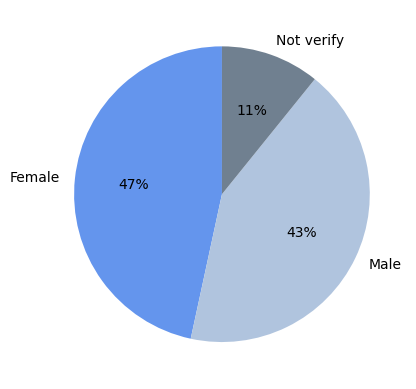

In [ ]:
#pie chart
plt.pie(df_gen['Total'],labels=df_gen['usergender'],colors=['cornflowerblue','lightsteelblue','slategrey'],autopct='%1.0f%%',startangle=90)

Note
-Nhoms khachs hàng chưa verify tài khoản chiếm 11% . Dẫn tới 2 TH


*   Nếu họ nhập dob thì sẽ có data
*   Nếu họ không nhập thì hệ thống sẽ auto fill là 1970->56 tuổi



In [ ]:
df_cus[df_cus['usergender']=='Not verify'].groupby('age').agg(
    Total=('customer_id','count')
).sort_values(by='Total',ascending=False).reset_index()

,age,Total
0,56,11435
1,31,124
2,32,120
3,28,117
4,30,114
5,29,113
6,33,103
7,34,101
8,27,93
9,36,87


In [ ]:
df_cus.head()

,customer_id,age,dob,usergender
0,100009,37,1989-02-25,Male
1,100493,35,1991-06-09,Male
2,100596,37,1989-05-18,Male
3,100852,29,1997-08-31,Male
4,100965,37,1988-09-20,Male


In [ ]:
# Viết hàm phân loại thế hệ
def get_generation(x):
  if x.year<1965:
    return 'baby boomers'
  elif x.year<1981:
    return 'Gen x'
  elif x.year<1996:
    return 'Gen y'
  else:
    return 'Gen z'

In [ ]:
# Logic phân loại x, y,z , baby boomer -> Dựa vào năm sinh
df_cus['age_generation ']=df_cus['dob'].apply(get_generation)


In [ ]:
print(df_cus.columns)

Index(['customer_id', 'age', 'dob', 'usergender', 'age_generation '], dtype='object')


In [ ]:
df_cus

,customer_id,age,dob,usergender,age_generation
0,100009,37,1989-02-25,Male,Gen y
1,100493,35,1991-06-09,Male,Gen y
2,100596,37,1989-05-18,Male,Gen y
3,100852,29,1997-08-31,Male,Gen z
4,100965,37,1988-09-20,Male,Gen y
...,...,...,...,...,...
154720,194726,25,2001-01-21,Male,Gen z
154721,211166,31,1995-05-05,Male,Gen y
154722,211671,46,1980-05-19,Male,Gen x
154723,223500,56,1970-01-01,Not verify,Gen x


In [ ]:
df_gen_group=df_cus[df_cus['usergender']!='Not verify'].groupby('age_generation ').agg(
    total_cus=('customer_id','count')

).reset_index().sort_values(by='total_cus',ascending=False)

Text(0.5, 1.0, 'Tỉ trọng phần trăm theo thế hệ ')

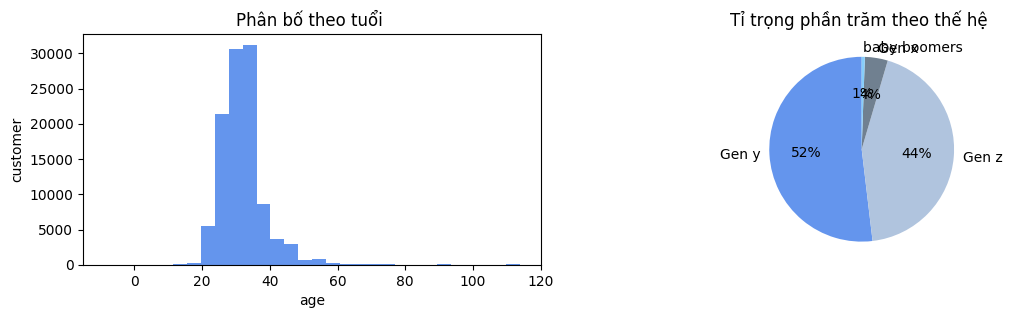

In [ ]:
#Ketse hợp 2 biểu đồ cùng luc
plt.figure(figsize=(13,3))
#plot 1
ax1=plt.subplot(1,2,1)
df_cus[df_cus['usergender']!='Not verify']['age'].hist(bins=30,color='cornflowerblue',grid=False)
plt.xlabel('age')
plt.ylabel('customer')
plt.title('Phân bố theo tuổi ')
#pie
ax2=plt.subplot(1,2,2)
plt.pie(df_gen_group['total_cus'],labels=df_gen_group['age_generation '],colors=['cornflowerblue','lightsteelblue','slategrey','lightskyblue'],autopct='%1.0f%%',startangle=90)
plt.title('Tỉ trọng phần trăm theo thế hệ ')



## 3.2 Time series data-when did customer buy ticket?

### Trend by month

In [ ]:
df_join_all.head()

,ticket_id,customer_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,campaign_id,movie_name,usergender,dob,campaign_type,description,error_group,model,platform,age_days,age
0,4f5200dcdcf2396b8d50ff84bf423f32,100009,money in app,13.0,244764a57dbdeb8fe9b164847ad55183,9.90,2.10,7.80,2022-07-08 17:46:36.145,1,83330,Thor: Love And Thunder,Male,1989-02-25,direct discount,Order successful,unknow,"iPhone13,1",mobile,13706,37
1,07abbaf28c772692f0367ad992bb3184,100493,bank account,180.0,8fa83cf46284aafd6e5da6c96f7862b5,8.66,1.48,7.18,2022-07-15 20:44:09.952,1,83330,Thor: Love And Thunder,Male,1991-06-09,direct discount,Order successful,unknow,browser,website,12872,35
2,1fdbeb7eceba8a27d9d985b5b70c219a,100596,money in app,56.0,69cf9244654949047f006e441fa7a8a7,10.31,2.31,8.00,2022-07-30 11:16:55.483,1,0,Thor: Love And Thunder,Male,1989-05-18,unknow,Order successful,unknow,unknow,mobile,13624,37
3,7715c9955866bd296b98543412839abd,100852,bank account,119.0,879ed11af9d6d2b5cda4d299590735a7,27.75,1.03,26.72,2022-07-04 22:33:07.458,1,85940,Thor: Love And Thunder,Male,1997-08-31,direct discount,Order successful,unknow,devicemodel,mobile,10597,29
4,776efd7bda0b715084430e6385f67746,100965,money in app,107.0,0a233600d993a02cc1d39fb0d87fc7de,4.33,1.03,3.30,2022-07-03 18:41:45.098,1,85940,Thor: Love And Thunder,Male,1988-09-20,direct discount,Order successful,unknow,devicemodel,mobile,13864,37


In [ ]:
df_join_all['month']=pd.to_datetime(df_join_all['time']).dt.month

In [ ]:
df_join_all.head(2)

,ticket_id,customer_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,campaign_id,movie_name,usergender,dob,campaign_type,description,error_group,model,platform,age_days,age,month
0,4f5200dcdcf2396b8d50ff84bf423f32,100009,money in app,13.0,244764a57dbdeb8fe9b164847ad55183,9.90,2.10,7.80,2022-07-08 17:46:36.145,1,83330,Thor: Love And Thunder,Male,1989-02-25,direct discount,Order successful,unknow,"iPhone13,1",mobile,13706,37,7
1,07abbaf28c772692f0367ad992bb3184,100493,bank account,180.0,8fa83cf46284aafd6e5da6c96f7862b5,8.66,1.48,7.18,2022-07-15 20:44:09.952,1,83330,Thor: Love And Thunder,Male,1991-06-09,direct discount,Order successful,unknow,browser,website,12872,35,7


In [ ]:
df_join_all['name_day']=pd.to_datetime(df_join_all['time']).dt.day_name()
df_join_all['hour']=pd.to_datetime(df_join_all['time']).dt.hour
df_join_all['year_month']=pd.to_datetime(df_join_all['time']).dt.strftime('%Y-%m')

In [ ]:
#Thống kê theo tháng
df_time_month=df_join_all.groupby('year_month').agg(
    total_tick=('ticket_id','count')

).reset_index()


In [ ]:
df_time_month.head(10)

,year_month,total_tick
0,2019-01,2019
1,2019-02,1626
2,2019-03,1004
3,2019-04,4069
4,2019-05,4430
5,2019-06,4387
6,2019-07,3872
7,2019-08,5444
8,2019-09,3278
9,2019-10,5284


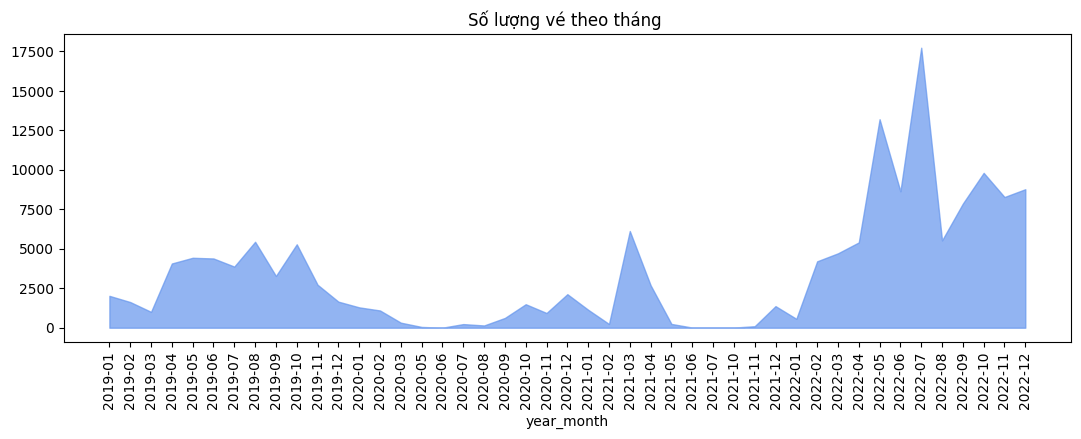

In [ ]:
#Vẽ biểu đồ miền theo tháng
plt.figure(figsize=(13,4))
plt.fill_between(df_time_month['year_month'],df_time_month['total_tick'],color='cornflowerblue',alpha=0.7)
plt.xticks(rotation=90)
plt.title('Số lượng vé theo tháng ')
plt.xlabel('year_month')

plt.show()



>>- Giai đoạn covid diễn ra - Người ta không đi xem phimg trong khaongr từ 2-8/2020 và từ 5-11/2021
>>- Sẽ cần có 1 bảng dim thời gian theo tháng -full - đầy đủ các tháng ( vì theo biểu đồ trên kia thì thì 1 số tháng bị thiếu )

In [ ]:
# Tạo bảng dim về thời gian để join lại với data ticket vẽ lại chart

In [ ]:
# Tạo bảng dimention về thời gian
# Xác định khoảng thời gian
start_date='2019-01-01'
end_date='2022-12-31'
# Tạo ra range thời gian từ 2 mốc bắt đầu và kết thúc
date_range=pd.date_range(start=start_date,end=end_date,freq='MS')# MS viết tắt của month_start
#Lấy ra list phần tử thời gian tương ứng :
list_month=date_range.month
list_month_name=date_range.strftime('%B')
list_year=date_range.year
list_year_month=date_range.strftime('%Y-%m')
#khởi tạo dataframe
dim_time=pd.DataFrame({
    'month':list_month,
    'month_name':list_month_name,
    'year':list_year,
    'year_month':list_year_month
})




In [ ]:
dim_time

,month,month_name,year,year_month
0,1,January,2019,2019-01
1,2,February,2019,2019-02
2,3,March,2019,2019-03
3,4,April,2019,2019-04
4,5,May,2019,2019-05
5,6,June,2019,2019-06
6,7,July,2019,2019-07
7,8,August,2019,2019-08
8,9,September,2019,2019-09
9,10,October,2019,2019-10


In [ ]:
#join voiws bảng df_join_all
df_time_month_dim=(
    pd.merge(dim_time,df_join_all,how='left',on='year_month')
    .groupby('year_month').agg(
        total_tick=('ticket_id','count')

    ).reset_index()
)

In [ ]:
df_time_month_dim

,year_month,total_tick
0,2019-01,2019
1,2019-02,1626
2,2019-03,1004
3,2019-04,4069
4,2019-05,4430
5,2019-06,4387
6,2019-07,3872
7,2019-08,5444
8,2019-09,3278
9,2019-10,5284


In [ ]:
df_time_month_dim.replace(0,np.nan,inplace=True)

Text(0.5, 1.0, 'Số lượng vé theo tháng ')

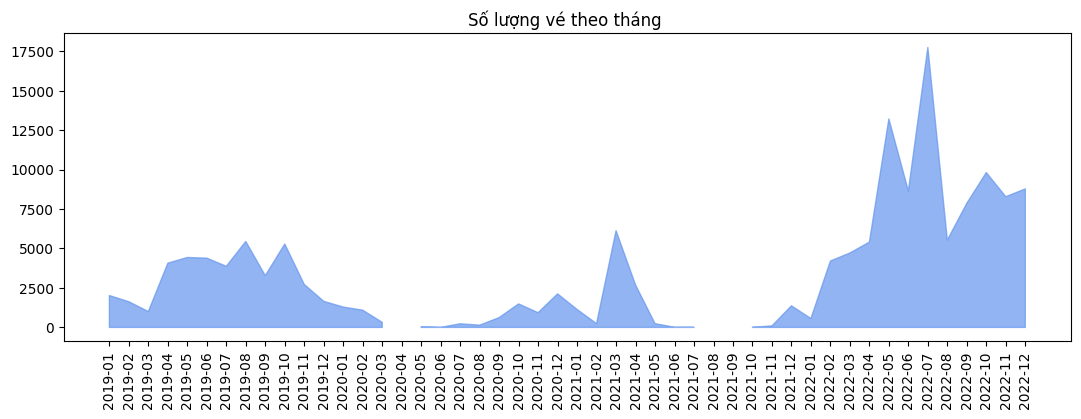

In [ ]:
plt.figure(figsize=(13,4))
plt.fill_between(df_time_month_dim['year_month'],df_time_month_dim['total_tick'],color='cornflowerblue',alpha=0.7)
plt.xticks(rotation=90)
plt.title('Số lượng vé theo tháng ')


### Trend by weekdays

In [ ]:
#Quan sát theo ngày trong tuần
df_join_all.head(2)


,ticket_id,customer_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,campaign_id,movie_name,usergender,dob,campaign_type,description,error_group,model,platform,age_days,age,month,name_day,hour,year_month
0,4f5200dcdcf2396b8d50ff84bf423f32,100009,money in app,13.0,244764a57dbdeb8fe9b164847ad55183,9.90,2.10,7.80,2022-07-08 17:46:36.145,1,83330,Thor: Love And Thunder,Male,1989-02-25,direct discount,Order successful,unknow,"iPhone13,1",mobile,13706,37,7,Friday,17,2022-07
1,07abbaf28c772692f0367ad992bb3184,100493,bank account,180.0,8fa83cf46284aafd6e5da6c96f7862b5,8.66,1.48,7.18,2022-07-15 20:44:09.952,1,83330,Thor: Love And Thunder,Male,1991-06-09,direct discount,Order successful,unknow,browser,website,12872,35,7,Friday,20,2022-07


In [ ]:
#Quan sát theo ngày trong tuần
df_week_day=(
    df_join_all.groupby('name_day').agg(
        total_tick=('ticket_id','count')
    ).reset_index()
)

In [ ]:
# Sắp xếp thứ tự các ngày trong tuần
week_order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df_week_day['day_order']=pd.Categorical(df_week_day['name_day'],categories=week_order,ordered=True)
df_week_day.sort_values(by='day_order',inplace=True)

Text(0.5, 1.0, 'Số lượng vé theo ngày trong tuần ')

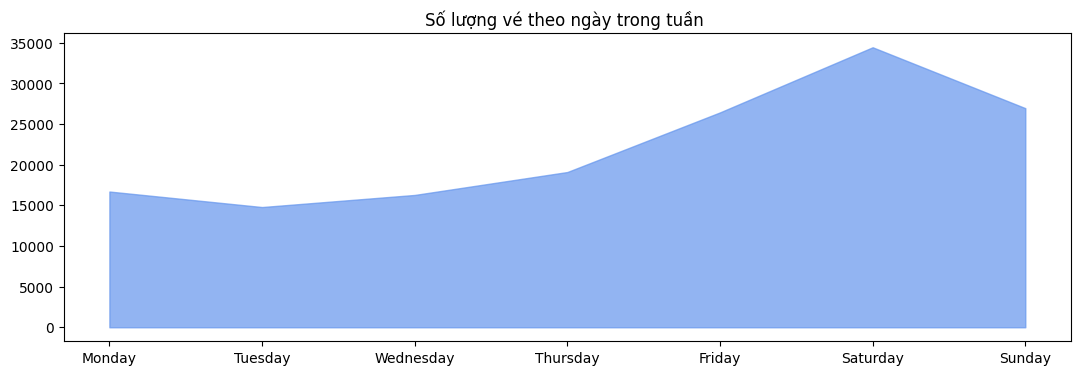

In [ ]:
#Vẽ biểu đồ
plt.figure(figsize=(13,4))
plt.fill_between(df_week_day['day_order'],df_week_day['total_tick'],color='cornflowerblue',alpha=0.7)
#plt.xticks(rotation=90)
plt.title('Số lượng vé theo ngày trong tuần ')

In [ ]:
# Sắp xếp thứ tự các ngày trong tuần
week_order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df_week_day['day_order']=pd.Categorical(df_week_day['name_day'],categories=week_order,ordered=True)
df_week_day.sort_values(by='day_order',inplace=True)

Text(0.5, 1.0, 'Số lượng vé bán theo ngày trong tuần  ')

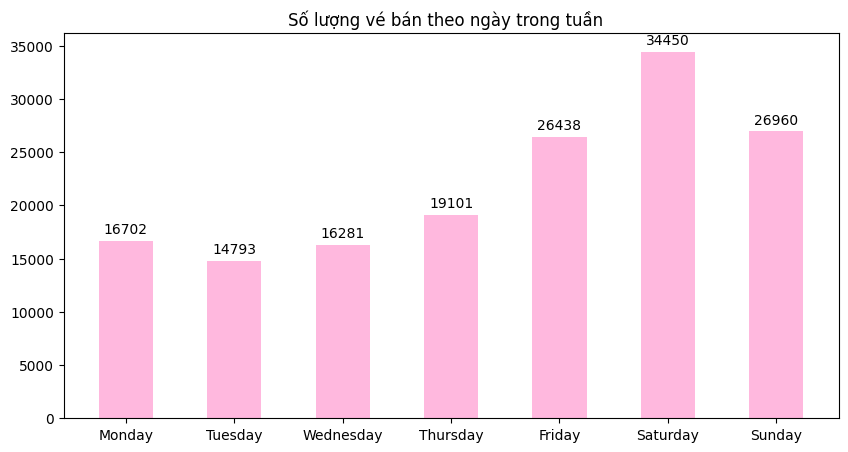

In [ ]:
plt.figure(figsize=(10,5))
cot=plt.bar(df_week_day['day_order'],df_week_day['total_tick'],color='deeppink',alpha=0.3,width=0.5)
plt.bar_label(cot,padding=3)
plt.title('Số lượng vé bán theo ngày trong tuần  ')


### Trend by hours

In [ ]:
df_join_all.head(2)

,ticket_id,customer_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,campaign_id,movie_name,usergender,dob,campaign_type,description,error_group,model,platform,age_days,age,month,name_day,hour,year_month
0,4f5200dcdcf2396b8d50ff84bf423f32,100009,money in app,13.0,244764a57dbdeb8fe9b164847ad55183,9.90,2.10,7.80,2022-07-08 17:46:36.145,1,83330,Thor: Love And Thunder,Male,1989-02-25,direct discount,Order successful,unknow,"iPhone13,1",mobile,13706,37,7,Friday,17,2022-07
1,07abbaf28c772692f0367ad992bb3184,100493,bank account,180.0,8fa83cf46284aafd6e5da6c96f7862b5,8.66,1.48,7.18,2022-07-15 20:44:09.952,1,83330,Thor: Love And Thunder,Male,1991-06-09,direct discount,Order successful,unknow,browser,website,12872,35,7,Friday,20,2022-07


In [ ]:
df_time_hour=df_join_all.groupby('hour').agg(
    total_tick=('ticket_id','count')

).reset_index()

Text(0.5, 1.0, 'Số lượng vé bán theo giờ ')

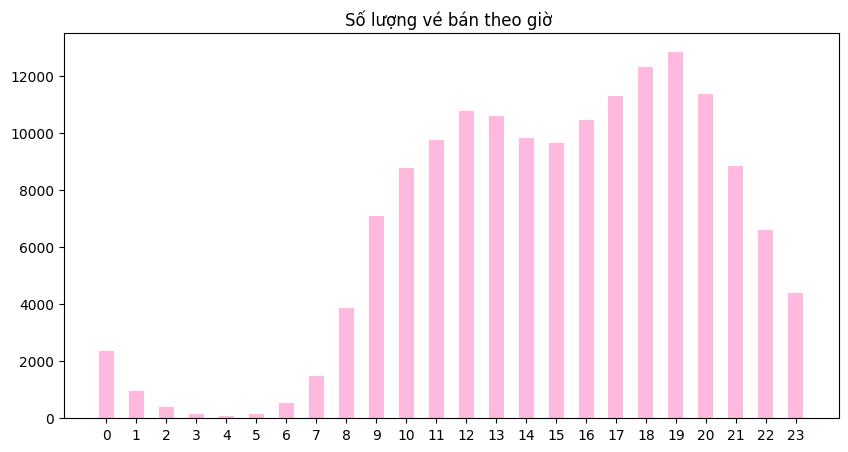

In [ ]:
plt.figure(figsize=(10,5))
cot=plt.bar(df_time_hour['hour'],df_time_hour['total_tick'],color='deeppink',alpha=0.3,width=0.5)
#plt.bar_label(cot,padding=3)
#đặt nhãn cho trục x từ 0-24 giờ
plt.xticks(range(24))
plt.title('Số lượng vé bán theo giờ ')


#

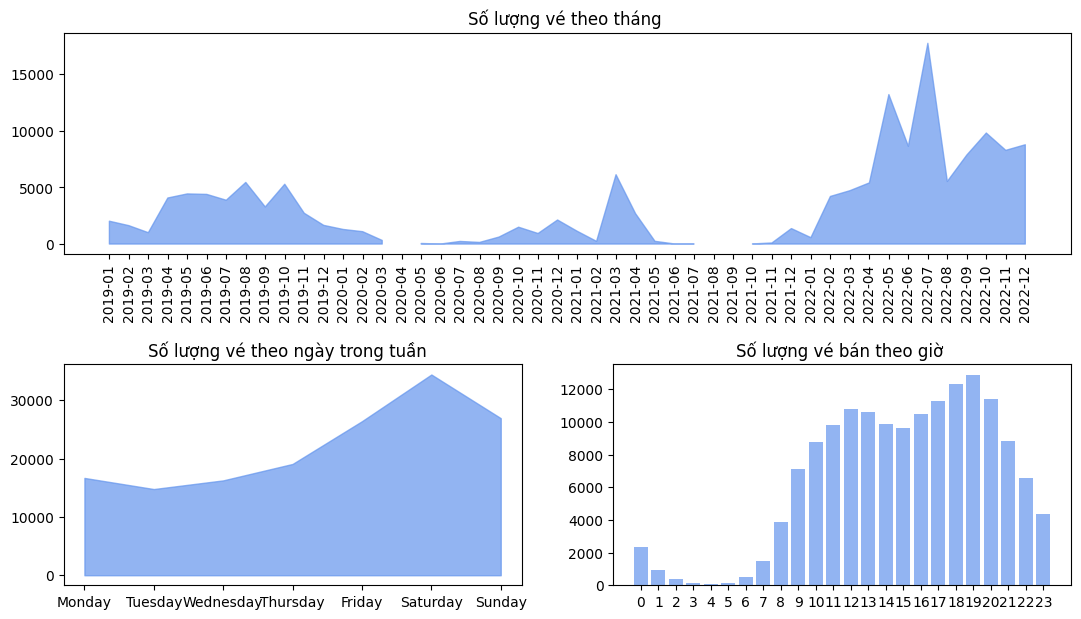

In [ ]:
plt.figure(figsize=(13,8))
#chart : Tháng
ax1=plt.subplot(2,1,1)
plt.fill_between(df_time_month_dim['year_month'],df_time_month_dim['total_tick'],color='cornflowerblue',alpha=0.7)
plt.xticks(rotation=90)
plt.title('Số lượng vé theo tháng ')
#chart: ngày trong tuần
ax2=plt.subplot(2,2,3)

plt.fill_between(df_week_day['day_order'],df_week_day['total_tick'],color='cornflowerblue',alpha=0.7)
plt.title('Số lượng vé theo ngày trong tuần  ')
#chart 3: theo giờ
ax3=plt.subplot(2,2,4)
cot=plt.bar(df_time_hour['hour'],df_time_hour['total_tick'],color='cornflowerblue',alpha=0.7)
#plt.bar_label(cot,padding=3)
#đặt nhãn cho trục x từ 0-24 giờ
plt.xticks(range(24))
plt.title('Số lượng vé bán theo giờ ')

plt.subplots_adjust(hspace=0.5,top=0.8)


## 3.3 Factors related to the customer's purchasing process


### Payment platform

In [ ]:
df_join_all.head(2)

,ticket_id,customer_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,campaign_id,movie_name,usergender,dob,campaign_type,description,error_group,model,platform,age_days,age,month,name_day,hour,year_month
0,4f5200dcdcf2396b8d50ff84bf423f32,100009,money in app,13.0,244764a57dbdeb8fe9b164847ad55183,9.90,2.10,7.80,2022-07-08 17:46:36.145,1,83330,Thor: Love And Thunder,Male,1989-02-25,direct discount,Order successful,unknow,"iPhone13,1",mobile,13706,37,7,Friday,17,2022-07
1,07abbaf28c772692f0367ad992bb3184,100493,bank account,180.0,8fa83cf46284aafd6e5da6c96f7862b5,8.66,1.48,7.18,2022-07-15 20:44:09.952,1,83330,Thor: Love And Thunder,Male,1991-06-09,direct discount,Order successful,unknow,browser,website,12872,35,7,Friday,20,2022-07


In [ ]:
df_platform=df_join_all[df_join_all['platform']!='unknow']\
.groupby('platform').agg(
    total_tick=('ticket_id','count')
).sort_values(by='total_tick',ascending=False).reset_index()


In [ ]:
df_platform

,platform,total_tick
0,mobile,138136
1,website,16511


/tmp/ipykernel_3525/1955508793.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right')


[Text(3, 0, '138136'), Text(3, 0, '16511')]

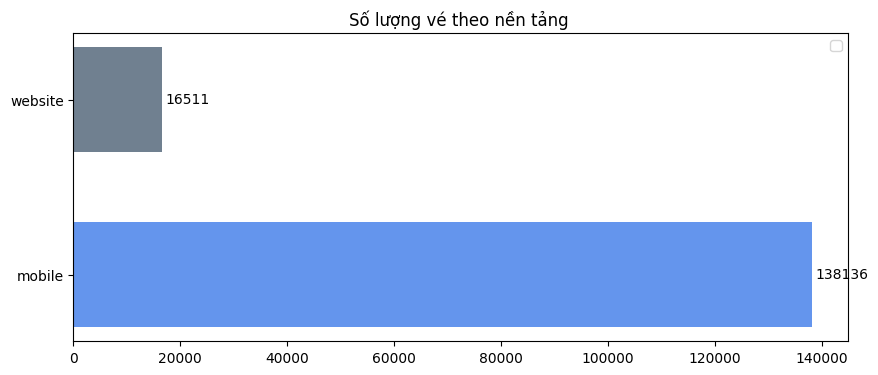

In [ ]:
#Biểu đồ cột ngang
plt.figure(figsize=(10,4))
cot=plt.barh(
    df_platform['platform'],df_platform['total_tick'],
    height=0.6,color=['cornflowerblue','slategrey']
    )
plt.title('Số lượng vé theo nền tảng ')
plt.legend(loc='upper right')
plt.bar_label(cot, padding=3)

Text(0.5, 1.0, 'Tỷ lệ phần trăm của từng nền tảng ')

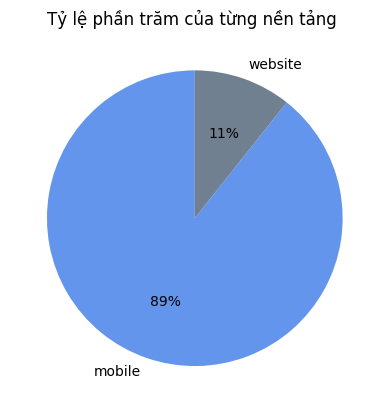

In [ ]:
#vẽ biẻu đồ tròn
#plt.pie(df_platform['total_tick'],labels=df_gen['usergender'],colors=['cornflowerblue','lightsteelblue','slategrey'],autopct='%1.0f%%',startangle=90)
plt.pie(df_platform['total_tick'],labels=df_platform['platform'],colors=['cornflowerblue','slategrey'],autopct='%1.0f%%',startangle=90)
plt.title('Tỷ lệ phần trăm của từng nền tảng ')

/tmp/ipykernel_3525/3608595294.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right')


Text(0.5, 1.0, 'Tỷ lệ phần trăm của từng nền tảng ')

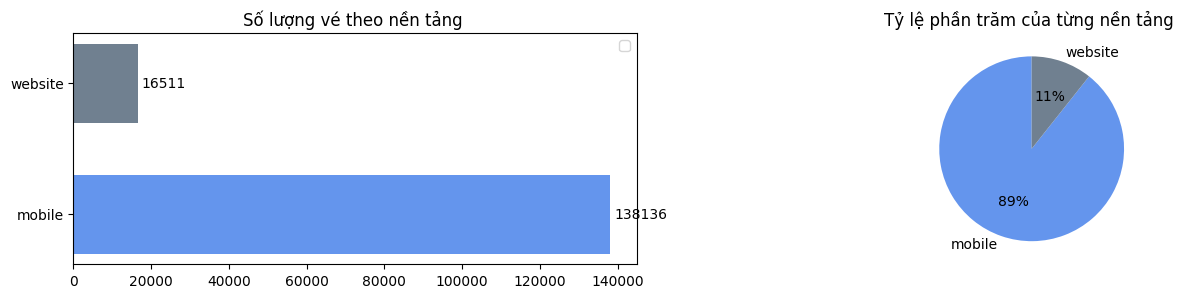

In [ ]:
#Bieeur dieenx chung
plt.figure(figsize=(16,3))
#cot
ax1=plt.subplot(1,2,1)
cot=plt.barh(
    df_platform['platform'],df_platform['total_tick'],
    height=0.6,color=['cornflowerblue','slategrey']
    )
plt.title('Số lượng vé theo nền tảng ')
plt.legend(loc='upper right')
plt.bar_label(cot, padding=3)
# tron
ax2=plt.subplot(1,2,2)
plt.pie(
    df_platform['total_tick'],labels=df_platform['platform'],
    colors=['cornflowerblue','slategrey'],autopct='%1.0f%%',startangle=90
    )
plt.title('Tỷ lệ phần trăm của từng nền tảng ')

In [ ]:
#view theo thời gian
df_platform_time=df_join_all[
    (df_join_all['description'] == 'Order successful') &
    (df_join_all['platform'] != 'unknow')
]\
.groupby(['year_month','platform']).agg(
    total_tick=('ticket_id','count')
).reset_index().sort_values(by='year_month',ascending=True)

In [ ]:
df_platform_time

,year_month,platform,total_tick
0,2019-01,mobile,1359
1,2019-02,mobile,1427
2,2019-03,mobile,866
3,2019-04,mobile,3190
4,2019-05,mobile,3617
...,...,...,...
66,2022-10,website,1674
67,2022-11,mobile,6104
68,2022-11,website,1467
69,2022-12,mobile,6479


In [ ]:
df_moblie=df_platform_time[df_platform_time['platform']=='mobile']
df_website=df_platform_time[df_platform_time['platform']=='website']


In [ ]:
df_moblie

,year_month,platform,total_tick
0,2019-01,mobile,1359
1,2019-02,mobile,1427
2,2019-03,mobile,866
3,2019-04,mobile,3190
4,2019-05,mobile,3617
5,2019-06,mobile,3604
6,2019-07,mobile,3165
7,2019-08,mobile,4514
8,2019-09,mobile,2772
9,2019-10,mobile,4336


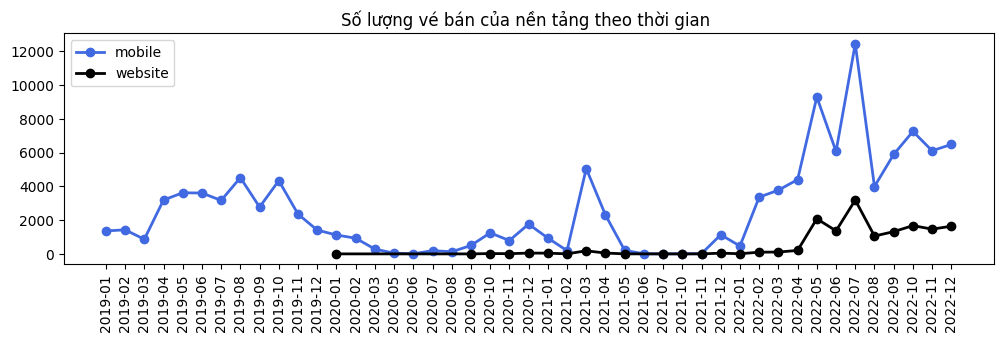

In [ ]:
# vex line chart
plt.figure(figsize=(12,3))
plt.plot(df_moblie['year_month'],df_moblie['total_tick'],color='royalblue',label='mobile',marker='o',linewidth=2)
plt.plot(df_website['year_month'],df_website['total_tick'],color='black',label='website',marker='o',linewidth=2)
plt.title('Số lượng vé bán của nền tảng theo thời gian ')
plt.xticks(rotation=90)
plt.legend(loc='upper left')

### OS version

In [ ]:
# vẽ theo biểu đồ miền
df_join_all.head(2)

,ticket_id,customer_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,campaign_id,movie_name,usergender,dob,campaign_type,description,error_group,model,platform,age_days,age,month,name_day,hour,year_month
0,4f5200dcdcf2396b8d50ff84bf423f32,100009,money in app,13.0,244764a57dbdeb8fe9b164847ad55183,9.90,2.10,7.80,2022-07-08 17:46:36.145,1,83330,Thor: Love And Thunder,Male,1989-02-25,direct discount,Order successful,unknow,"iPhone13,1",mobile,13706,37,7,Friday,17,2022-07
1,07abbaf28c772692f0367ad992bb3184,100493,bank account,180.0,8fa83cf46284aafd6e5da6c96f7862b5,8.66,1.48,7.18,2022-07-15 20:44:09.952,1,83330,Thor: Love And Thunder,Male,1991-06-09,direct discount,Order successful,unknow,browser,website,12872,35,7,Friday,20,2022-07


In [ ]:
#phân tích vê thiết bị sử dụng
#phân nhóm thiết bị về androi và ios và unknow,browser
df_join_all['os_version']=df_join_all['model'].apply(lambda x: 'ios'if('iPhone'in x or'ipod'in x )
                                                      else'browser'if('browser'in x)
                                                      else 'unknow'if('devicemodel'in x or'unknow'in x)
                                                      else 'android $ other'
)



In [ ]:
df_join_all['os_version'].unique()

array(['ios', 'browser', 'unknow', 'android $ other'], dtype=object)

In [ ]:
# groupby để thống kê
df_os=df_join_all.groupby('os_version').agg(
    total_tick=('ticket_id','count')
).reset_index().sort_values(by='total_tick',ascending=False)

In [ ]:
df_os

,os_version,total_tick
3,unknow,68854
2,ios,51400
0,android $ other,21094
1,browser,13377


/tmp/ipykernel_3525/3329575395.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right')


Text(0.5, 1.0, 'Tỷ lệ phần trăm theo thiết bị  ')

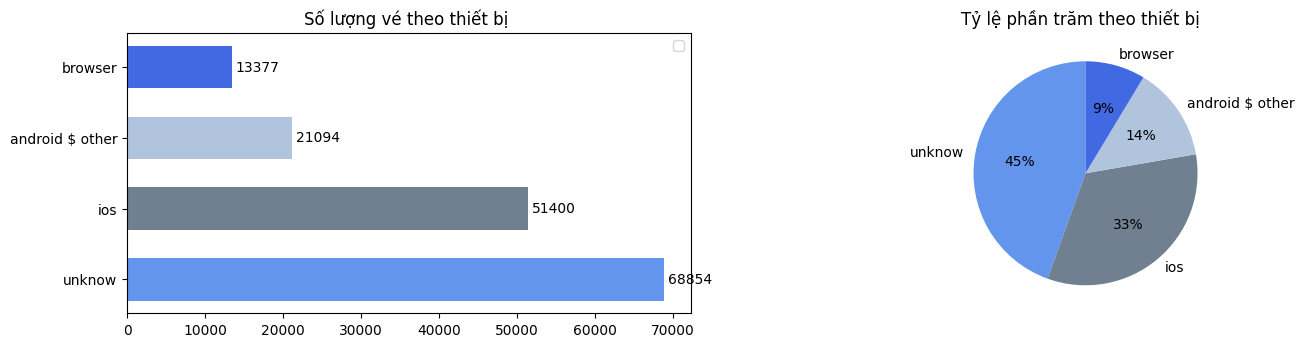

In [ ]:
plt.figure(figsize=(16,8))
#cot
ax1=plt.subplot(2,2,1)
cot=plt.barh(
    df_os['os_version'],df_os['total_tick'],
    height=0.6,color=['cornflowerblue','slategrey','lightsteelblue','royalblue']
    )
plt.title('Số lượng vé theo thiết bị ')
plt.legend(loc='upper right')
plt.bar_label(cot, padding=3)
# tron
ax2=plt.subplot(2,2,2)
plt.pie(
    df_os['total_tick'],labels=df_os['os_version'],
    colors=['cornflowerblue','slategrey','lightsteelblue','royalblue'],autopct='%1.0f%%',startangle=90
    )
plt.title('Tỷ lệ phần trăm theo thiết bị  ')



In [ ]:
#Theo dõi theo thời gian

In [ ]:
df_join_all.groupby(['year_month','os_version']).agg(
    total_tick=('ticket_id','count')
).reset_index().sort_values(by='year_month',ascending=True)


,year_month,os_version,total_tick
0,2019-01,android $ other,713
1,2019-01,ios,1233
2,2019-01,unknow,73
3,2019-02,android $ other,542
4,2019-02,ios,1074
...,...,...,...
134,2022-11,browser,1078
138,2022-12,browser,1202
139,2022-12,ios,2124
137,2022-12,android $ other,88


In [ ]:
#df_moblie=df_platform_time[df_platform_time['platform']=='mobile']#
#Xử lý data dạng pivot để vẽ biểu đồ miền
df_os_time=(
    df_join_all
    .pivot_table(index='year_month',columns='os_version',aggfunc='count',values='ticket_id')
    .reset_index()
)


In [ ]:
df_os_time

os_version,year_month,android $ other,browser,ios,unknow
0,2019-01,713.0,NaN,1233.0,73.0
1,2019-02,542.0,NaN,1074.0,10.0
2,2019-03,371.0,NaN,631.0,2.0
3,2019-04,1520.0,NaN,2540.0,9.0
4,2019-05,1601.0,NaN,2826.0,3.0
5,2019-06,1575.0,NaN,2808.0,4.0
6,2019-07,1373.0,NaN,2499.0,NaN
7,2019-08,1797.0,NaN,3642.0,5.0
8,2019-09,1122.0,NaN,2151.0,5.0
9,2019-10,1964.0,NaN,3313.0,7.0


Text(0.5, 1.0, 'số lượng vế theo thiêt bị ')

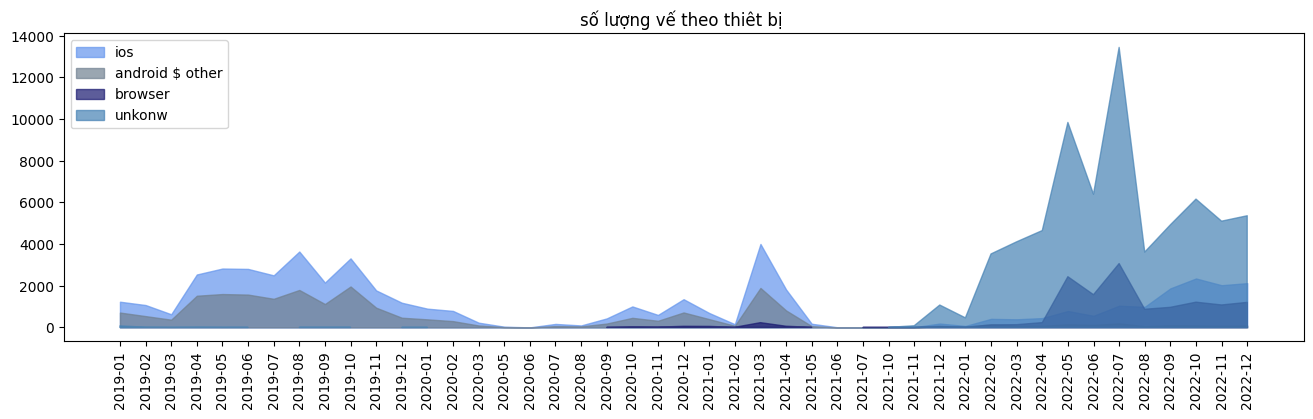

In [ ]:
#vẼ BIỂU ĐỒ MIỀN VỀ THỜI GIAN
plt.figure(figsize=(16,4))
plt.fill_between(df_os_time['year_month'],df_os_time['ios'],color='cornflowerblue',alpha=0.7,label='ios')
plt.fill_between(df_os_time['year_month'],df_os_time['android $ other'],color='slategrey',alpha=0.7,label='android $ other')
plt.fill_between(df_os_time['year_month'],df_os_time['browser'],color='midnightblue',alpha=0.7,label='browser')
plt.fill_between(df_os_time['year_month'],df_os_time['unknow'],color='steelblue',alpha=0.7,label='unkonw')
plt.legend(loc='upper left')
plt.xticks(rotation=90)
plt.title('số lượng vế theo thiêt bị ')



/tmp/ipykernel_3525/3992378010.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right')


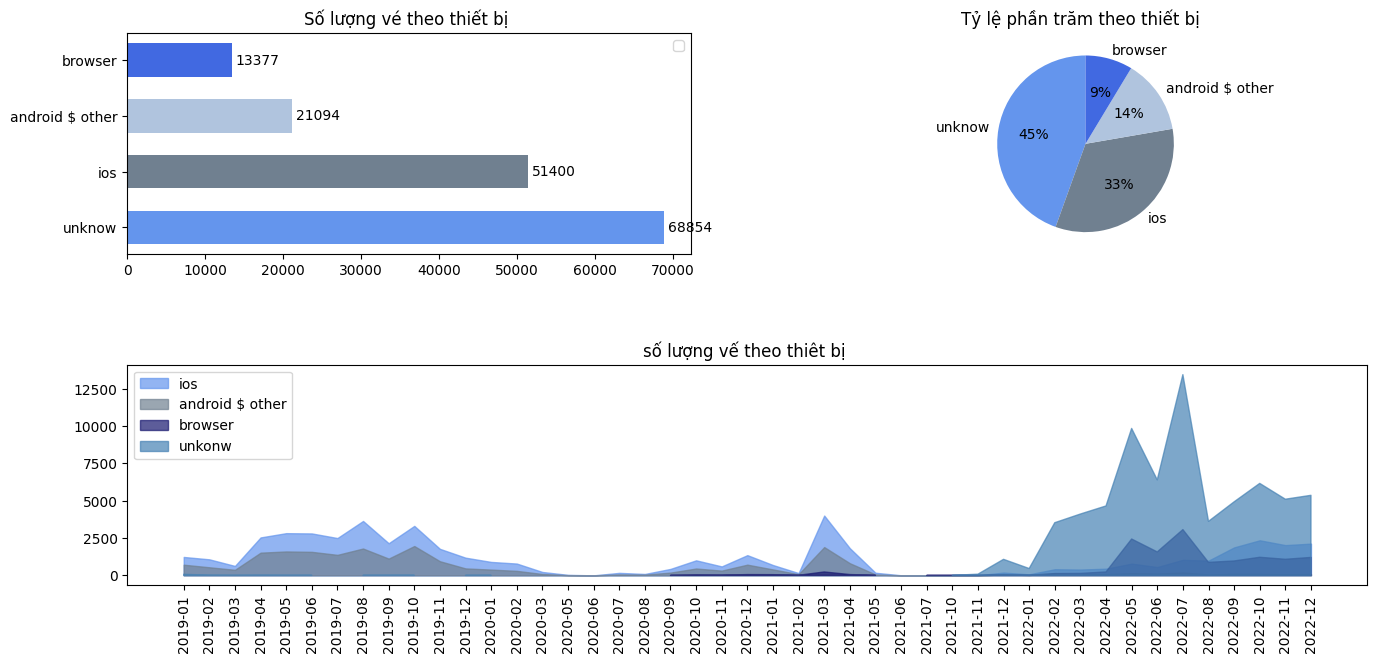

In [ ]:
#Bieuer diễn chung 1 frame
plt.figure(figsize=(16,8))
#cot
ax1=plt.subplot(2,2,1)
cot=plt.barh(
    df_os['os_version'],df_os['total_tick'],
    height=0.6,color=['cornflowerblue','slategrey','lightsteelblue','royalblue']
    )
plt.title('Số lượng vé theo thiết bị ')
plt.legend(loc='upper right')
plt.bar_label(cot, padding=3)
# tron
ax2=plt.subplot(2,2,2)
plt.pie(
    df_os['total_tick'],labels=df_os['os_version'],
    colors=['cornflowerblue','slategrey','lightsteelblue','royalblue'],autopct='%1.0f%%',startangle=90
    )
plt.title('Tỷ lệ phần trăm theo thiết bị  ')
#mien
ax3=plt.subplot(2,1,2)
plt.fill_between(df_os_time['year_month'],df_os_time['ios'],color='cornflowerblue',alpha=0.7,label='ios')
plt.fill_between(df_os_time['year_month'],df_os_time['android $ other'],color='slategrey',alpha=0.7,label='android $ other')
plt.fill_between(df_os_time['year_month'],df_os_time['browser'],color='midnightblue',alpha=0.7,label='browser')
plt.fill_between(df_os_time['year_month'],df_os_time['unknow'],color='steelblue',alpha=0.7,label='unkonw')
plt.legend(loc='upper left')
plt.xticks(rotation=90)
plt.title('số lượng vế theo thiêt bị ')
plt.subplots_adjust(hspace=0.5,top=0.8)




In [ ]:
df_join_all.head(2)

,ticket_id,customer_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,campaign_id,movie_name,usergender,dob,campaign_type,description,error_group,model,platform,age_days,age,month,name_day,hour,year_month,os_version
0,4f5200dcdcf2396b8d50ff84bf423f32,100009,money in app,13.0,244764a57dbdeb8fe9b164847ad55183,9.90,2.10,7.80,2022-07-08 17:46:36.145,1,83330,Thor: Love And Thunder,Male,1989-02-25,direct discount,Order successful,unknow,"iPhone13,1",mobile,13706,37,7,Friday,17,2022-07,ios
1,07abbaf28c772692f0367ad992bb3184,100493,bank account,180.0,8fa83cf46284aafd6e5da6c96f7862b5,8.66,1.48,7.18,2022-07-15 20:44:09.952,1,83330,Thor: Love And Thunder,Male,1991-06-09,direct discount,Order successful,unknow,browser,website,12872,35,7,Friday,20,2022-07,browser


### payment method

In [ ]:
df_method=df_join_all[(df_join_all['status_id']==1)&(df_join_all['paying_method']!='other')].groupby('paying_method').agg(
    total_tick=('ticket_id','count')

).reset_index().sort_values(by='total_tick',ascending=True)

In [ ]:
df_method

,paying_method,total_tick
2,debit card,11395
1,credit card,15408
0,bank account,42057
3,money in app,64817


In [ ]:
#xử lý data dang pivot
df_method_time=(
    df_join_all[(df_join_all['status_id']==1)&(df_join_all['paying_method']!='other')]
    .pivot_table(index='year_month',columns='paying_method',aggfunc='count',values='ticket_id')
    .reset_index()
)

In [ ]:
df_method_time

paying_method,year_month,bank account,credit card,debit card,money in app
0,2019-01,487.0,336.0,93.0,443.0
1,2019-02,484.0,370.0,93.0,480.0
2,2019-03,304.0,225.0,74.0,263.0
3,2019-04,1050.0,705.0,189.0,1246.0
4,2019-05,1092.0,903.0,212.0,1410.0
5,2019-06,1074.0,962.0,249.0,1319.0
6,2019-07,916.0,782.0,252.0,1215.0
7,2019-08,1367.0,1142.0,321.0,1684.0
8,2019-09,774.0,711.0,219.0,1068.0
9,2019-10,1280.0,914.0,309.0,1833.0


/tmp/ipykernel_3525/2125824449.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right')


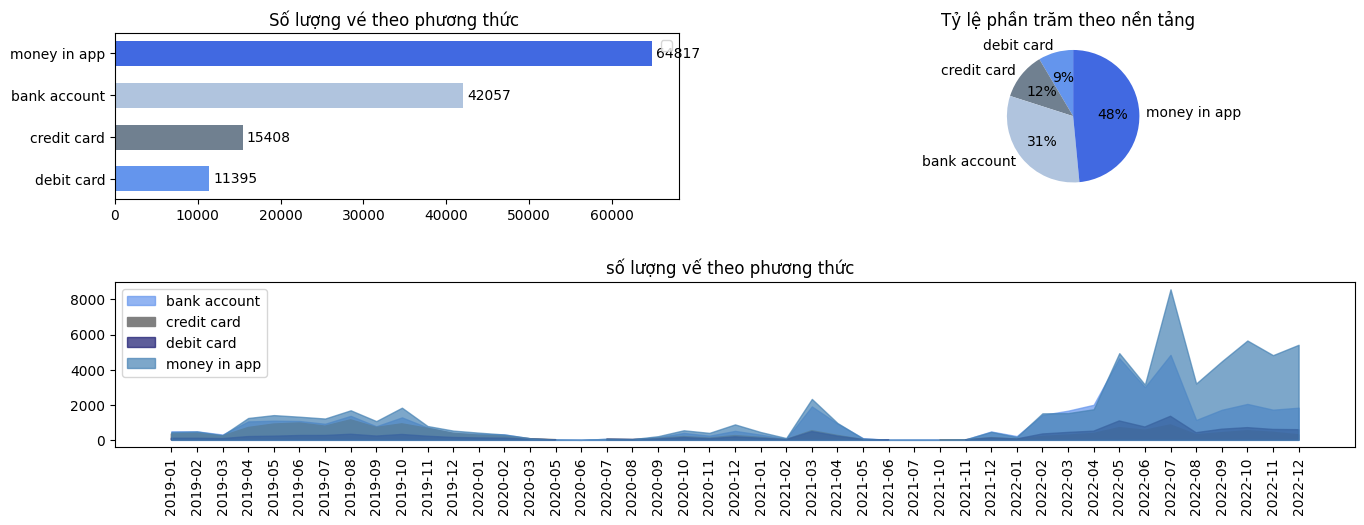

In [ ]:
#Bieuer diễn chung 1 frame
plt.figure(figsize=(16,6))
#cot
ax1=plt.subplot(2,2,1)
cot=plt.barh(
    df_method['paying_method'],df_method['total_tick'],
    color=['cornflowerblue','slategrey','lightsteelblue','royalblue'],
    height=0.6
)
plt.title('Số lượng vé theo phương thức ')
plt.legend(loc='upper right')
plt.bar_label(cot, padding=3)
# tron
ax2=plt.subplot(2,2,2)
plt.pie(
    df_method['total_tick'],labels=df_method['paying_method'],
    colors=['cornflowerblue','slategrey','lightsteelblue','royalblue'],autopct='%1.0f%%',startangle=90
    )
plt.title('Tỷ lệ phần trăm theo nền tảng  ')
#mien
ax3=plt.subplot(2,1,2)
plt.fill_between(df_method_time['year_month'],df_method_time['bank account'],color='cornflowerblue',alpha=0.7,label='bank account')
plt.fill_between(df_method_time['year_month'],df_method_time['credit card'],color='grey',label='credit card')
plt.fill_between(df_method_time['year_month'],df_method_time['debit card'],color='midnightblue',alpha=0.7,label='debit card')
plt.fill_between(df_method_time['year_month'],df_method_time['money in app'],color='steelblue',alpha=0.7,label='money in app')
plt.legend(loc='upper left')
plt.xticks(rotation=90)
plt.title('số lượng vế theo phương thức  ')
plt.subplots_adjust(hspace=0.5,top=0.8)





In [ ]:
#Vẽ biểu đồ miền tính 100%
#Tính tỷ trọng phần trăm mỗi phương thức theo thang
df_method_time=(
    df_join_all[(df_join_all['status_id']==1)&(df_join_all['paying_method']!='other')]
    .pivot_table(index='year_month',columns='paying_method',aggfunc='count',values='ticket_id')
    .reset_index()
)
df_method_time_pct=df_method_time.copy()
df_method_time_pct=df_method_time_pct.fillna(0)
df_method_time_pct['total']=df_method_time_pct.iloc[:,1:].sum(axis=1)
for i in df_method_time_pct.columns[1:5]:
  df_method_time_pct[i+'_ptc']=  df_method_time_pct[i]/df_method_time_pct['total']


In [ ]:
df_method_time_pct

paying_method,year_month,bank account,credit card,debit card,money in app,total,bank account_ptc,credit card_ptc,debit card_ptc,money in app_ptc
0,2019-01,487.0,336.0,93.0,443.0,1359.0,0.358352,0.247241,0.068433,0.325975
1,2019-02,484.0,370.0,93.0,480.0,1427.0,0.339173,0.259285,0.065172,0.336370
2,2019-03,304.0,225.0,74.0,263.0,866.0,0.351039,0.259815,0.085450,0.303695
3,2019-04,1050.0,705.0,189.0,1246.0,3190.0,0.329154,0.221003,0.059248,0.390596
4,2019-05,1092.0,903.0,212.0,1410.0,3617.0,0.301908,0.249654,0.058612,0.389826
5,2019-06,1074.0,962.0,249.0,1319.0,3604.0,0.298002,0.266926,0.069090,0.365982
6,2019-07,916.0,782.0,252.0,1215.0,3165.0,0.289415,0.247077,0.079621,0.383886
7,2019-08,1367.0,1142.0,321.0,1684.0,4514.0,0.302836,0.252991,0.071112,0.373062
8,2019-09,774.0,711.0,219.0,1068.0,2772.0,0.279221,0.256494,0.079004,0.385281
9,2019-10,1280.0,914.0,309.0,1833.0,4336.0,0.295203,0.210793,0.071264,0.422740


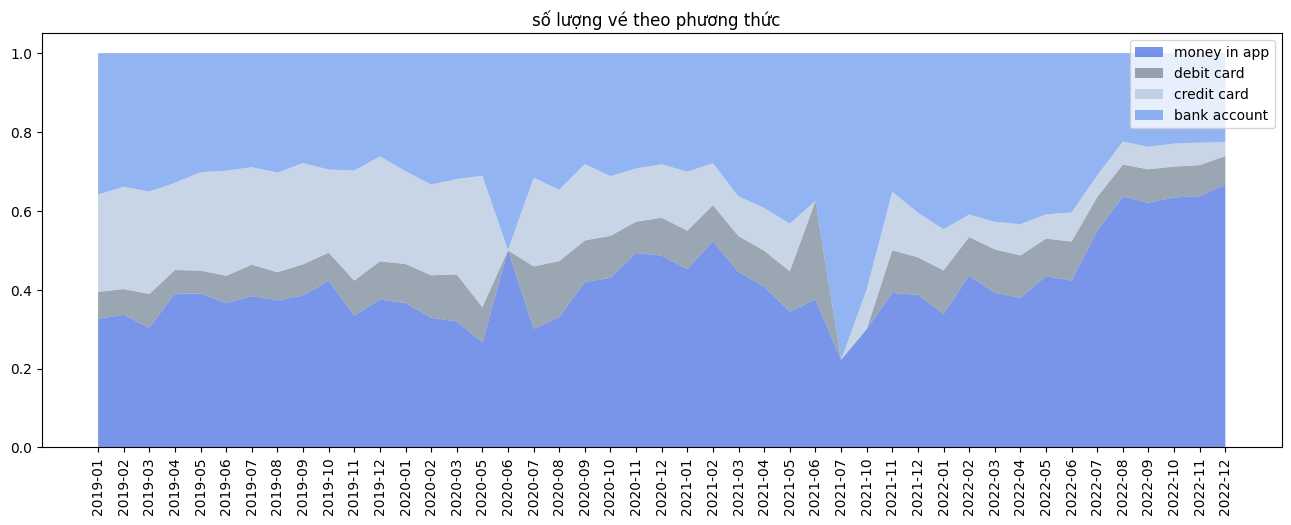

In [ ]:
#Vẽ biểu đồ miền 100%
#cú pháp vẽ biểu đồ miền 100%
plt.figure(figsize=(16,6))
plt.stackplot(df_method_time_pct['year_month'],
              df_method_time_pct["money in app_ptc"],
              df_method_time_pct['debit card_ptc'],
              df_method_time_pct['credit card_ptc'],
              df_method_time_pct['bank account_ptc']
              ,labels=['money in app', 'debit card', 'credit card', 'bank account'],
              colors=['royalblue', 'slategrey', 'lightsteelblue', 'cornflowerblue'], alpha=0.7)
plt.xticks(rotation=90)
plt.title('số lượng vé theo phương thức  ')
plt.legend(loc='upper right')
plt.subplots_adjust(hspace=0.5,top=0.8)


/tmp/ipykernel_3525/1116257747.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right')


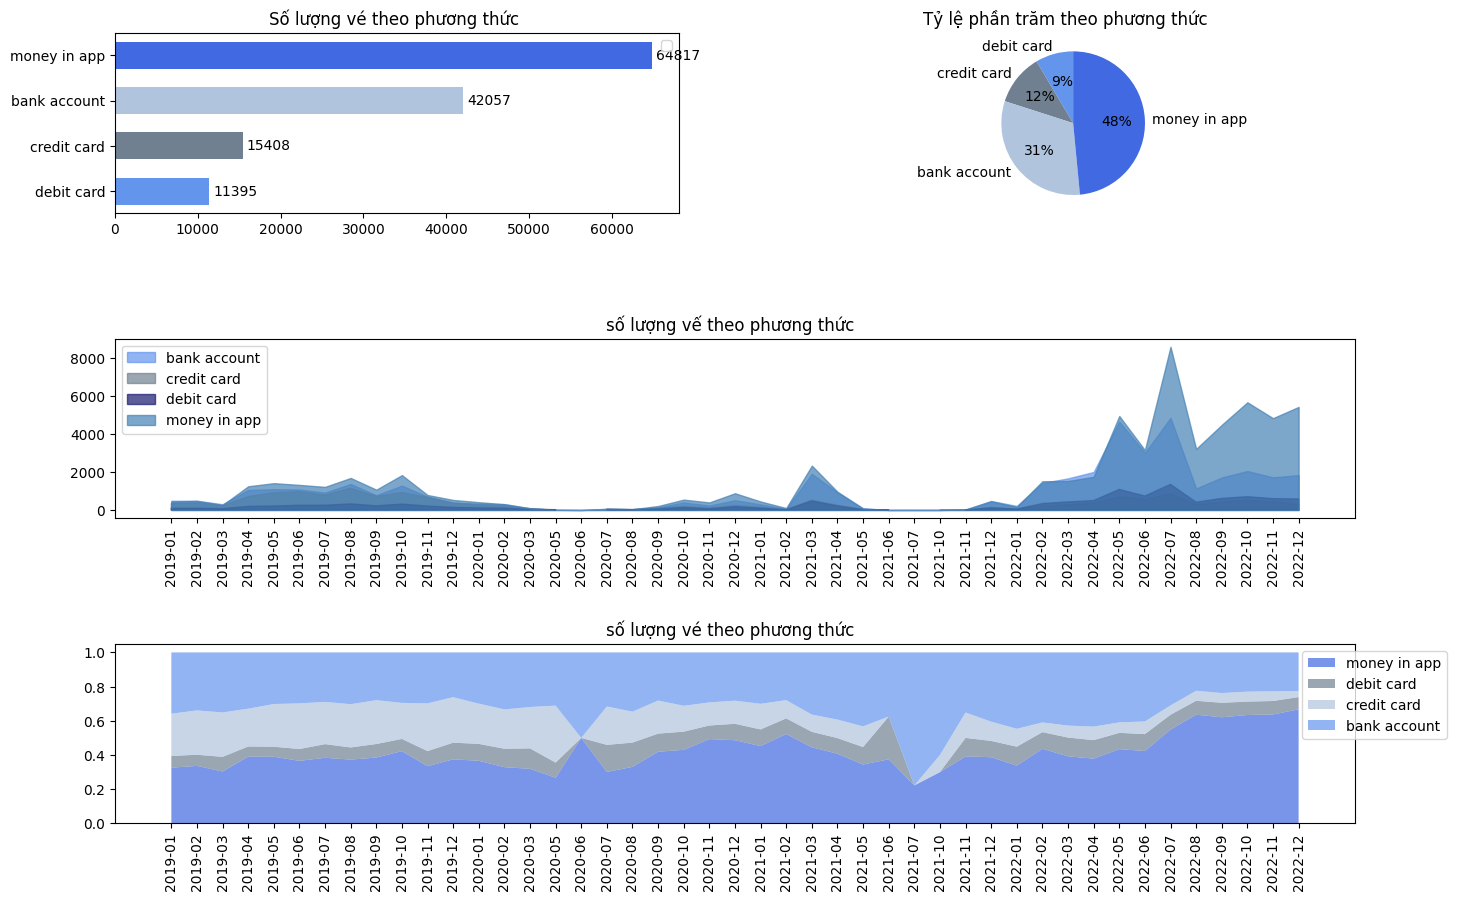

In [ ]:
#Bieuer diễn chung 1 frame
plt.figure(figsize=(16,10))
#cot
ax1=plt.subplot(3,2,1)
cot=plt.barh(
    df_method['paying_method'],df_method['total_tick'],
    color=['cornflowerblue','slategrey','lightsteelblue','royalblue'],
    height=0.6
)
plt.title('Số lượng vé theo phương thức ')
plt.legend(loc='upper right')
plt.bar_label(cot, padding=3)
# tron
ax2=plt.subplot(3,2,2)
plt.pie(
    df_method['total_tick'],labels=df_method['paying_method'],
    colors=['cornflowerblue','slategrey','lightsteelblue','royalblue'],autopct='%1.0f%%',startangle=90
    )
plt.title('Tỷ lệ phần trăm theo phương thức   ')
#mien
ax3=plt.subplot(3,1,2)
plt.fill_between(df_method_time['year_month'],df_method_time['bank account'],color='cornflowerblue',alpha=0.7,label='bank account')
plt.fill_between(df_method_time['year_month'],df_method_time['credit card'],color='slategrey',alpha=0.7,label='credit card')
plt.fill_between(df_method_time['year_month'],df_method_time['debit card'],color='midnightblue',alpha=0.7,label='debit card')
plt.fill_between(df_method_time['year_month'],df_method_time['money in app'],color='steelblue',alpha=0.7,label='money in app')
plt.legend(loc='upper left')
plt.xticks(rotation=90)
plt.title('số lượng vế theo phương thức  ')
plt.subplots_adjust(hspace=0.5,top=0.8)
#mien100%
ax4=plt.subplot(3,1,3)
plt.stackplot(df_method_time_pct['year_month'],
              df_method_time_pct["money in app_ptc"],
              df_method_time_pct['debit card_ptc'],
              df_method_time_pct['credit card_ptc'],
              df_method_time_pct['bank account_ptc']
              ,labels=['money in app', 'debit card', 'credit card', 'bank account'],
              colors=['royalblue', 'slategrey', 'lightsteelblue', 'cornflowerblue'], alpha=0.7)
plt.xticks(rotation=90)
plt.title('số lượng vé theo phương thức  ')
plt.legend(loc='upper right',bbox_to_anchor=(1.08,1))
plt.subplots_adjust(hspace=0.7,top=0.9)


### Promotion

In [ ]:
df_join_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 154725 entries, 0 to 154724
Data columns (total 26 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   ticket_id       154725 non-null  object        
 1   customer_id     154725 non-null  int64         
 2   paying_method   154725 non-null  object        
 3   theater_name    154725 non-null  float64       
 4   device_number   154725 non-null  object        
 5   original_price  154725 non-null  float64       
 6   discount_value  154725 non-null  float64       
 7   final_price     154725 non-null  float64       
 8   time            154725 non-null  datetime64[ns]
 9   status_id       154725 non-null  int64         
 10  campaign_id     154725 non-null  int64         
 11  movie_name      154725 non-null  object        
 12  usergender      154725 non-null  object        
 13  dob             154725 non-null  datetime64[ns]
 14  campaign_type   154725 non-null  obj

In [ ]:
df_campaign.head()

,campaign_id,campaign_type
0,106460,direct discount
1,30040,direct discount
2,13810,voucher
3,78370,voucher
4,83700,voucher


In [ ]:
df_join_all['campaign_type'].unique()

array(['direct discount', 'unknow', 'voucher', 'reward point'],
      dtype=object)

In [ ]:
df_join_all['type']=df_join_all['campaign_type'].apply(lambda x:'none-promotion'if x=='unknow'else'promotion')

In [ ]:
df_join_all.head(2)

,ticket_id,customer_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,campaign_id,movie_name,usergender,dob,campaign_type,description,error_group,model,platform,age_days,age,month,name_day,hour,year_month,os_version,type
0,4f5200dcdcf2396b8d50ff84bf423f32,100009,money in app,13.0,244764a57dbdeb8fe9b164847ad55183,9.90,2.10,7.80,2022-07-08 17:46:36.145,1,83330,Thor: Love And Thunder,Male,1989-02-25,direct discount,Order successful,unknow,"iPhone13,1",mobile,13706,37,7,Friday,17,2022-07,ios,promotion
1,07abbaf28c772692f0367ad992bb3184,100493,bank account,180.0,8fa83cf46284aafd6e5da6c96f7862b5,8.66,1.48,7.18,2022-07-15 20:44:09.952,1,83330,Thor: Love And Thunder,Male,1991-06-09,direct discount,Order successful,unknow,browser,website,12872,35,7,Friday,20,2022-07,browser,promotion


In [ ]:
df_type=df_join_all[(df_join_all['status_id']==1)&(df_join_all['paying_method']!='other')].groupby('type').agg(
    total_tick=('ticket_id','count')

).reset_index().sort_values(by='total_tick',ascending=True)

In [ ]:
df_type.head()

,type,total_tick
0,none-promotion,55155
1,promotion,78522


In [ ]:
df_type_time=(
    df_join_all[(df_join_all['status_id']==1)&(df_join_all['paying_method']!='other')]
    .pivot_table(index='year_month',columns='type',aggfunc='count',values='ticket_id').reset_index()
)
df_type_time_pct=df_type_time.copy()
df_type_time_pct=df_type_time_pct.fillna(0)
df_type_time_pct['total']=df_type_time_pct.iloc[:,1:].sum(axis=1)
for i in df_type_time_pct.columns[1:3]:
  df_type_time_pct[i+'_ptc']=  df_type_time_pct[i]/df_type_time_pct['total']

In [ ]:
df_type_time_pct.head()

type,year_month,none-promotion,promotion,total,none-promotion_ptc,promotion_ptc
0,2019-01,517.0,842.0,1359.0,0.380427,0.619573
1,2019-02,1335.0,92.0,1427.0,0.935529,0.064471
2,2019-03,835.0,31.0,866.0,0.964203,0.035797
3,2019-04,1699.0,1491.0,3190.0,0.532602,0.467398
4,2019-05,1564.0,2053.0,3617.0,0.432403,0.567597


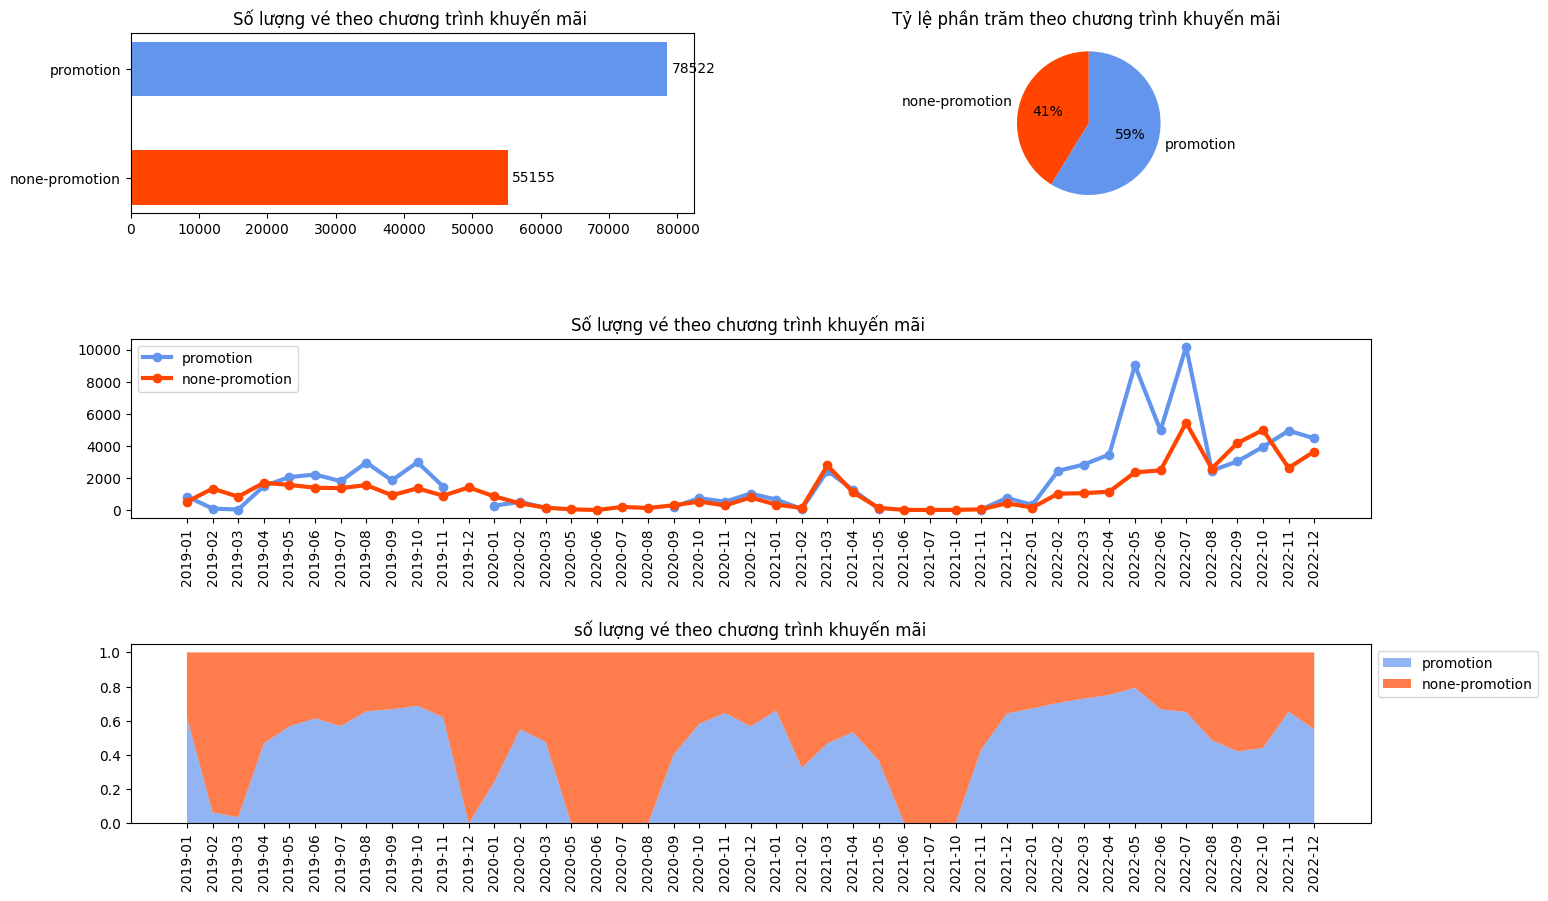

In [ ]:
#vẽ biểu đồ
plt.figure(figsize=(16,10))
ax1=plt.subplot(3,2,1)
cot=plt.barh(
    df_type['type'],df_type['total_tick'],color=df_type['type'].replace({'promotion':'cornflowerblue','none-promotion':'orangered'})
    ,height=0.5

)
plt.bar_label(cot, padding=3)
plt.title('Số lượng vé theo chương trình khuyến mãi ')
# tròn
ax2=plt.subplot(3,2,2)
plt.pie(
    df_type['total_tick'],labels=df_type['type'],
    colors=df_type['type'].replace({'promotion':'cornflowerblue','none-promotion':'orangered'})
    ,autopct='%1.0f%%',startangle=90
)
plt.title('Tỷ lệ phần trăm theo chương trình khuyến mãi ')
#Biểu đồ đường
ax3=plt.subplot(3,1,2)
plt.plot(df_type_time['year_month'],df_type_time['promotion'],color='cornflowerblue',label='promotion',marker='o',linewidth=3)
plt.plot(df_type_time['year_month'],df_type_time['none-promotion'],color='orangered',label='none-promotion',marker='o',linewidth=3)
plt.xticks(rotation=90)
plt.legend(loc='upper left')
plt.title('Số lượng vé theo chương trình khuyến mãi ')

#Biểu đồ miền 100%
ax4=plt.subplot(3,1,3)
plt.stackplot(df_type_time_pct['year_month'],
              df_type_time_pct["promotion_ptc"],
              df_type_time_pct['none-promotion_ptc'],
              labels=['promotion','none-promotion'],
              colors=['cornflowerblue','orangered'],alpha=0.7)
plt.xticks(rotation=90)
plt.legend(loc='upper left',bbox_to_anchor=(1.0,1))
plt.title('số lượng vé theo chương trình khuyến mãi')

plt.subplots_adjust(hspace=0.7,top=0.9)

### Which movies they watched



In [ ]:
df_join_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 154725 entries, 0 to 154724
Data columns (total 27 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   ticket_id       154725 non-null  object        
 1   customer_id     154725 non-null  int64         
 2   paying_method   154725 non-null  object        
 3   theater_name    154725 non-null  float64       
 4   device_number   154725 non-null  object        
 5   original_price  154725 non-null  float64       
 6   discount_value  154725 non-null  float64       
 7   final_price     154725 non-null  float64       
 8   time            154725 non-null  datetime64[ns]
 9   status_id       154725 non-null  int64         
 10  campaign_id     154725 non-null  int64         
 11  movie_name      154725 non-null  object        
 12  usergender      154725 non-null  object        
 13  dob             154725 non-null  datetime64[ns]
 14  campaign_type   154725 non-null  obj

In [ ]:
df_join_all.head(2)

,ticket_id,customer_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,campaign_id,movie_name,usergender,dob,campaign_type,description,error_group,model,platform,age_days,age,month,name_day,hour,year_month,os_version,type
0,4f5200dcdcf2396b8d50ff84bf423f32,100009,money in app,13.0,244764a57dbdeb8fe9b164847ad55183,9.90,2.10,7.80,2022-07-08 17:46:36.145,1,83330,Thor: Love And Thunder,Male,1989-02-25,direct discount,Order successful,unknow,"iPhone13,1",mobile,13706,37,7,Friday,17,2022-07,ios,promotion
1,07abbaf28c772692f0367ad992bb3184,100493,bank account,180.0,8fa83cf46284aafd6e5da6c96f7862b5,8.66,1.48,7.18,2022-07-15 20:44:09.952,1,83330,Thor: Love And Thunder,Male,1991-06-09,direct discount,Order successful,unknow,browser,website,12872,35,7,Friday,20,2022-07,browser,promotion


In [ ]:
df_film_sum=(
    df_join_all[df_join_all['status_id']==1]
    .groupby('movie_name').agg(
        total_tick=('ticket_id','count'),
        total_sale=('final_price','sum'),
        total_customer=('customer_id','nunique')

    ).sort_values(by='total_tick',ascending=False).reset_index()

)

In [ ]:
df_film_sum.head(20)

,movie_name,total_tick,total_sale,total_customer
0,Doctor Strange In The Multiverse Of Madness,8615,65579.98,8409
1,Minions: The Rise Of Gru,7224,56530.93,7014
2,Avatar: The Way Of Water,5870,59830.95,5612
3,Thor: Love And Thunder,5589,43372.90,5478
4,Peninsula,5499,41208.44,5365
5,Black Panther 2: Wakanda Forever,3847,26860.28,3790
6,Black Adam,3229,23159.34,3186
7,Avengers: Endgame,3219,26690.48,3135
8,Dad I'm Sorry,3023,25863.28,2817
9,Love Destiny,2411,18345.61,2376


In [ ]:
list_film=df_film_sum[df_film_sum['total_tick']>1000]['movie_name'].unique()
list_selected_film=list(list_film)#chuyeenr danh sách tên phim ở mảng thành list

In [ ]:
list_selected_film

['Doctor Strange In The Multiverse Of Madness',
 'Minions: The Rise Of Gru',
 'Avatar: The Way Of Water',
 'Thor: Love And Thunder',
 'Peninsula',
 'Black Panther 2: Wakanda Forever',
 'Black Adam',
 'Avengers: Endgame',
 "Dad I'm Sorry",
 'Love Destiny',
 'You And Trinh',
 'Fast & Furious Presents: Hobbs & Shaw',
 'Emergency Declaration',
 'Jurassic World Dominion',
 'Godzilla Vs. Kong',
 'Detective Conan: The Bride Of Halloween',
 'Joker',
 'Spider-Man: No Way Home',
 'Batman',
 'Blood Moon Party',
 'Fantastic Beasts: Secrets Of Dumbledore',
 'Top Gun: Maverick',
 'Naked Truth',
 "Doraemon: Nobita's Little Star Wars 2021",
 'One Piece Film: Red',
 'Confidential Assignment 2: International',
 'Extremely Easy Job',
 'Morbius',
 'Spider-Man Far From Home',
 'Maleficent',
 'Face Off: 48h',
 'Parasite']

In [ ]:
df_movie_time=(
    df_join_all[(df_join_all['status_id']==1)&(df_join_all['movie_name'].isin(list_selected_film))]
    .pivot_table(index='year_month',columns='movie_name',aggfunc='count',values='ticket_id').reset_index()
)

In [ ]:
df_movie_time

movie_name,year_month,Avatar: The Way Of Water,Avengers: Endgame,Batman,Black Adam,Black Panther 2: Wakanda Forever,Blood Moon Party,Confidential Assignment 2: International,Dad I'm Sorry,Detective Conan: The Bride Of Halloween,Doctor Strange In The Multiverse Of Madness,Doraemon: Nobita's Little Star Wars 2021,Emergency Declaration,Extremely Easy Job,Face Off: 48h,Fantastic Beasts: Secrets Of Dumbledore,Fast & Furious Presents: Hobbs & Shaw,Godzilla Vs. Kong,Joker,Jurassic World Dominion,Love Destiny,Maleficent,Minions: The Rise Of Gru,Morbius,Naked Truth,One Piece Film: Red,Parasite,Peninsula,Spider-Man Far From Home,Spider-Man: No Way Home,Thor: Love And Thunder,Top Gun: Maverick,You And Trinh
0,2019-04,NaN,2081.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-05,NaN,1130.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2019-06,NaN,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,751.0,NaN,28.0,NaN,NaN,NaN,NaN
3,2019-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,126.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,286.0,NaN,1125.0,NaN,NaN,NaN,NaN
4,2019-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1950.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2019-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.0,NaN,34.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2019-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1405.0,NaN,NaN,1008.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2019-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,79.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2020-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.0,NaN,NaN,NaN,NaN,NaN,NaN
9,2020-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN


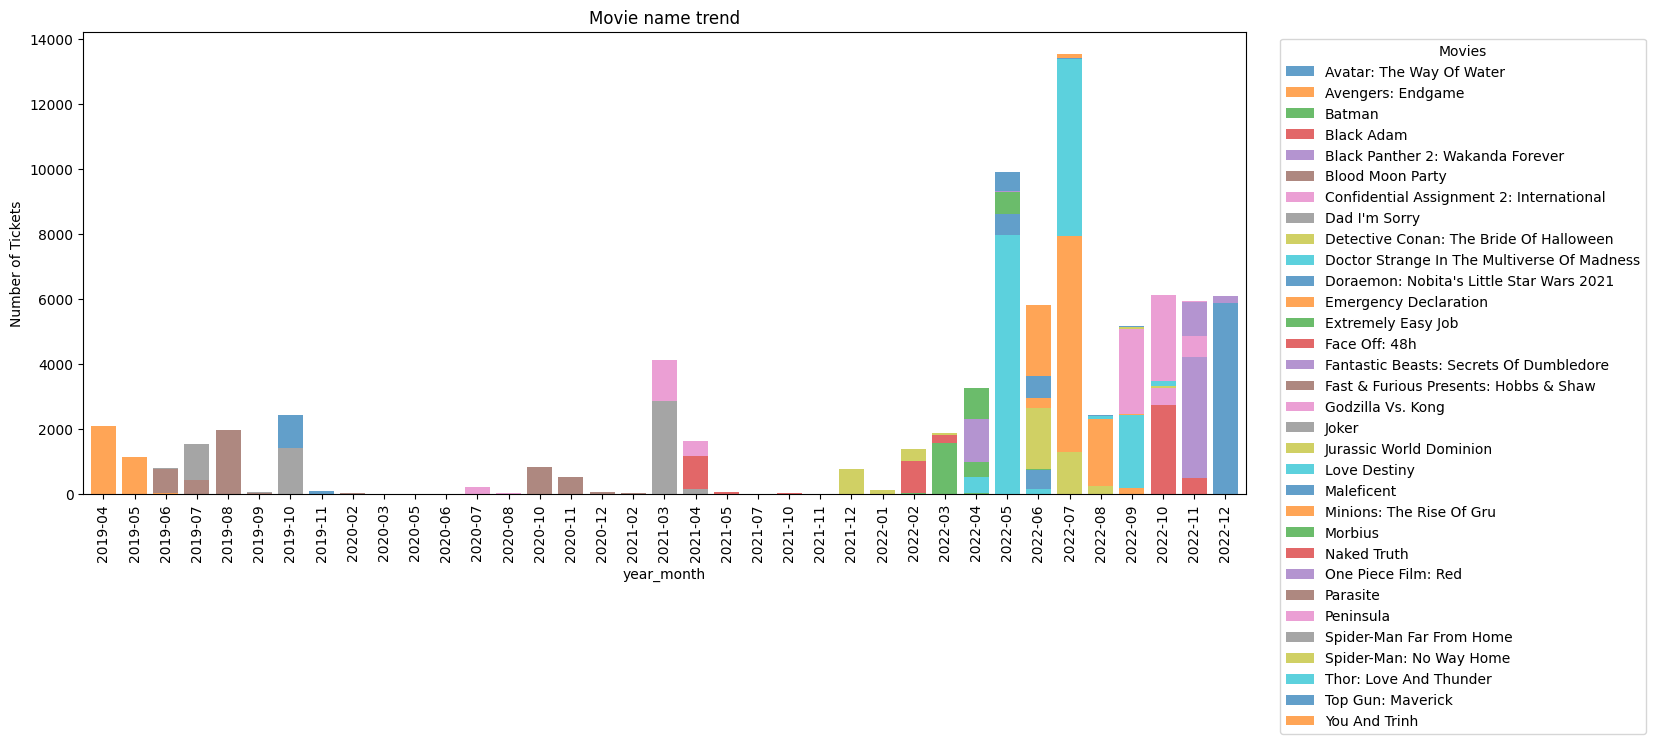

In [ ]:
#Biểu đồ cột chồng
ax = df_movie_time.plot(x = 'year_month', kind='bar', stacked=True, figsize=(15, 6), width=0.8, alpha = 0.7)

# Set the title and labels
ax.set_title('Movie name trend')
# ax.set_xlabel('Month')
ax.set_ylabel('Number of Tickets')

# Add a legend
plt.legend(title='Movies', loc='upper right', bbox_to_anchor=(1.35, 1))

# Show the plot
plt.show()

## 3.4 Customer values dimension




*   **Mục tiêu phân tích các chỉ số về giá trị mà 1 khách hàng mang lại**
>>- Frequency: count, day , month
>>- Monetary:total_money,total_discount
>>- Success rate: number_success/Total
>>- Promotion_rate: number_promotion/Total_success
>>- Discount_rate:sum_discount/sum_money








### Frequency & anomaly behavior

In [ ]:
# Tính tất cả các chỉ số trên
# Tính các chỉ số cho những thanh toán thành công
# Đếm số lượng vé co khuyến mãi

In [ ]:
df_join_all.head(2)

,ticket_id,customer_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,campaign_id,movie_name,usergender,dob,campaign_type,description,error_group,model,platform,age_days,age,month,name_day,hour,year_month,os_version,type
0,4f5200dcdcf2396b8d50ff84bf423f32,100009,money in app,13.0,244764a57dbdeb8fe9b164847ad55183,9.90,2.10,7.80,2022-07-08 17:46:36.145,1,83330,Thor: Love And Thunder,Male,1989-02-25,direct discount,Order successful,unknow,"iPhone13,1",mobile,13706,37,7,Friday,17,2022-07,ios,promotion
1,07abbaf28c772692f0367ad992bb3184,100493,bank account,180.0,8fa83cf46284aafd6e5da6c96f7862b5,8.66,1.48,7.18,2022-07-15 20:44:09.952,1,83330,Thor: Love And Thunder,Male,1991-06-09,direct discount,Order successful,unknow,browser,website,12872,35,7,Friday,20,2022-07,browser,promotion


In [ ]:
def calculate_n_promotion(x):
  return (x=='promotion').sum()
df_success_metric=(
    df_join_all[df_join_all['status_id']==1]
    .assign(date=pd.to_datetime(df_join_all['time']).dt.date)
    .groupby('customer_id').agg(
        n_success=('ticket_id','count'),
        s_money=('original_price','sum'),
        s_discount=('discount_value','sum'),
        n_date=('date','nunique'),
        n_month=('year_month','nunique'),
        n_promotion=('type',calculate_n_promotion)

    ).reset_index()

)

In [ ]:
df_success_metric.head(2)

,customer_id,n_success,s_money,s_discount,n_date,n_month,n_promotion
0,100001,1,7.42,2.06,1,1,1
1,100003,6,60.95,2.56,6,6,1


In [ ]:
# Các chỉ số tổng và số giao dịch lỗi
def calculate_n_failed(x):
  return (x!=1).sum()
df_failed_metric=(
    df_join_all
    .groupby('customer_id')
    .agg(
        n_total=('ticket_id','count'),
        n_failed=('status_id',calculate_n_failed)
    ).reset_index()

)

In [ ]:
df_failed_metric.head(2)

,customer_id,n_total,n_failed
0,100001,1,0
1,100003,6,0


In [ ]:
# merge bang success vaf bang fail
df_customer_value=(
    pd.merge(df_failed_metric,df_success_metric,how='left',on='customer_id')
    .fillna(0)
)

In [ ]:
df_customer_value.head(2)

,customer_id,n_total,n_failed,n_success,s_money,s_discount,n_date,n_month,n_promotion
0,100001,1,0,1.0,7.42,2.06,1.0,1.0,1.0
1,100003,6,0,6.0,60.95,2.56,6.0,6.0,1.0


In [ ]:
df_customer_value['success_rate']=df_customer_value['n_success']/df_customer_value['n_total']
df_customer_value['promotion_rate']=df_customer_value['n_promotion']/df_customer_value['n_success']
df_customer_value['discount_rate']=df_customer_value['s_discount']/df_customer_value['s_money']

array([[<Axes: title={'center': 'n_total'}>,
        <Axes: title={'center': 'n_failed'}>,
        <Axes: title={'center': 'n_success'}>],
       [<Axes: title={'center': 's_money'}>,
        <Axes: title={'center': 's_discount'}>,
        <Axes: title={'center': 'n_date'}>],
       [<Axes: title={'center': 'n_month'}>,
        <Axes: title={'center': 'n_promotion'}>,
        <Axes: title={'center': 'success_rate'}>],
       [<Axes: title={'center': 'promotion_rate'}>,
        <Axes: title={'center': 'discount_rate'}>, <Axes: >]],
      dtype=object)

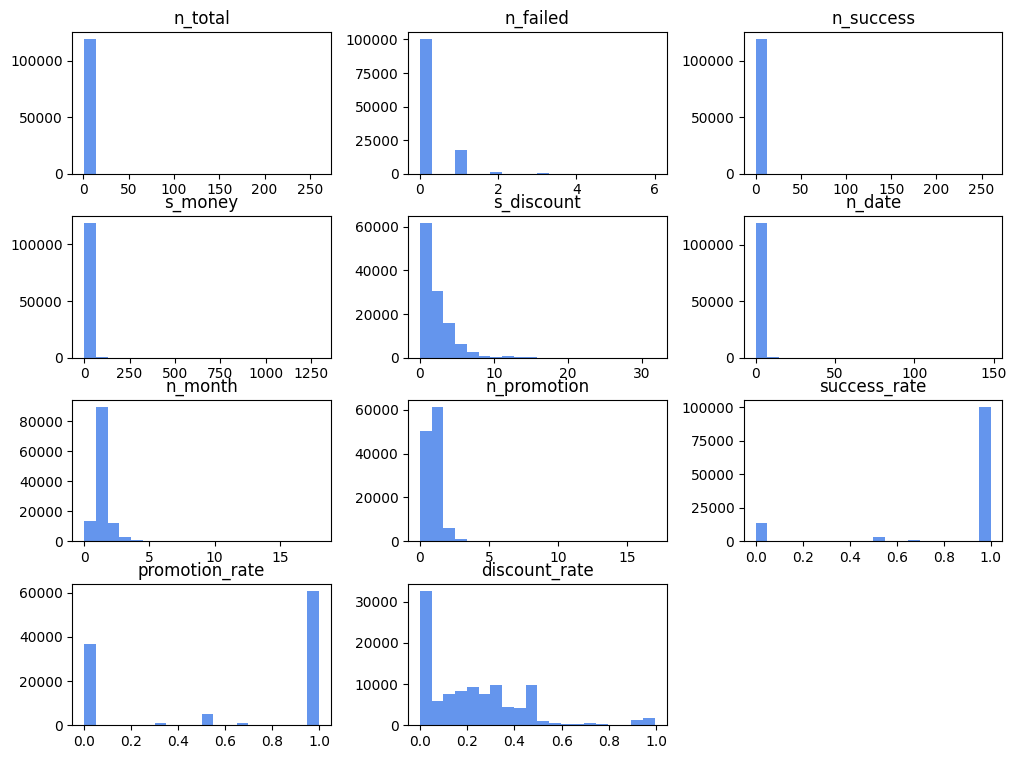

In [ ]:
#visualize taats car chir so bang histogram
# dung iloc[]: để lấy những column mk muốn
df_customer_value.iloc[:,1:].hist(figsize=(12,9),grid=False,color='cornflowerblue',bins=20)


** Notes**

- **n_total**: Hầu hết khách hàng mua vé rất ít (1–2 vé), nhưng có một nhóm nhỏ mua cực nhiều (tới 250 vé) → cần kiểm tra những người này.  
- **n_failed**: Có hơn 100k khách hàng bị fail ít nhất 1 lần.  
- **n_success_rate**: Khoảng 10% giao dịch có success_rate = 0.  
- **promotion_rate**: Hơn 60k khách hàng chỉ tham gia promotion (rate = 100).  
- **discount_rate**: Có những khách hàng hưởng được mức giảm giá 100%.  
- **n_promotion**: Số lượng khách hàng hưởng khuyến mãi 1 lần rất cao (trên 60k). → Cần kiểm tra xem có liên quan đến nhóm **promotion_rate = 100%** hay không.


#

In [ ]:
# Có những khách hàng mua vé rất ít, cũng có những khách hàng mua vé rất nhiều
df_customer_value['n_order_dis']=df_customer_value['n_success'].apply(lambda x:'more than 10' if x>=10 else str(x) )

In [ ]:
df_customer_value['n_order_dis'].unique()

array(['1.0', '6.0', '7.0', '2.0', '0.0', '4.0', '3.0', '5.0',
       'more than 10', '8.0', '9.0'], dtype=object)

In [ ]:
df_n_dis=(
    df_customer_value.groupby('n_order_dis').agg(
    total_cus=('customer_id','count')
).reset_index()
)


In [ ]:
df_n_dis

,n_order_dis,total_cus
0,0.0,13701
1,1.0,87921
2,2.0,12902
3,3.0,3145
4,4.0,1017
5,5.0,380
6,6.0,168
7,7.0,92
8,8.0,47
9,9.0,30


In [ ]:
df_customer_value[df_customer_value['n_order_dis']=='more than 10']

,customer_id,n_total,n_failed,n_success,s_money,s_discount,n_date,n_month,n_promotion,success_rate,promotion_rate,discount_rate,n_order_dis
110,100125,11,1,10.0,93.89,3.59,10.0,9.0,2.0,0.909091,0.200000,0.038236,more than 10
182,100205,10,0,10.0,104.14,9.33,10.0,8.0,3.0,1.000000,0.300000,0.089591,more than 10
737,100818,15,1,14.0,64.37,9.32,14.0,9.0,5.0,0.933333,0.357143,0.144788,more than 10
2117,102326,12,1,11.0,39.14,0.00,11.0,5.0,0.0,0.916667,0.000000,0.000000,more than 10
2283,102508,17,0,17.0,141.16,0.00,15.0,3.0,0.0,1.000000,0.000000,0.000000,more than 10
...,...,...,...,...,...,...,...,...,...,...,...,...,...
111563,222641,51,0,51.0,240.84,2.31,41.0,11.0,3.0,1.000000,0.058824,0.009591,more than 10
114016,225396,17,0,17.0,87.91,21.08,4.0,2.0,17.0,1.000000,1.000000,0.239791,more than 10
115005,226527,49,0,49.0,339.56,12.79,38.0,7.0,5.0,1.000000,0.102041,0.037666,more than 10
115304,226886,37,0,37.0,186.01,1.90,27.0,5.0,1.0,1.000000,0.027027,0.010215,more than 10


[Text(3, 0, '13701'),
 Text(3, 0, '87921'),
 Text(3, 0, '12902'),
 Text(3, 0, '3145'),
 Text(3, 0, '1017'),
 Text(3, 0, '380'),
 Text(3, 0, '168'),
 Text(3, 0, '92'),
 Text(3, 0, '47'),
 Text(3, 0, '30'),
 Text(3, 0, '74')]

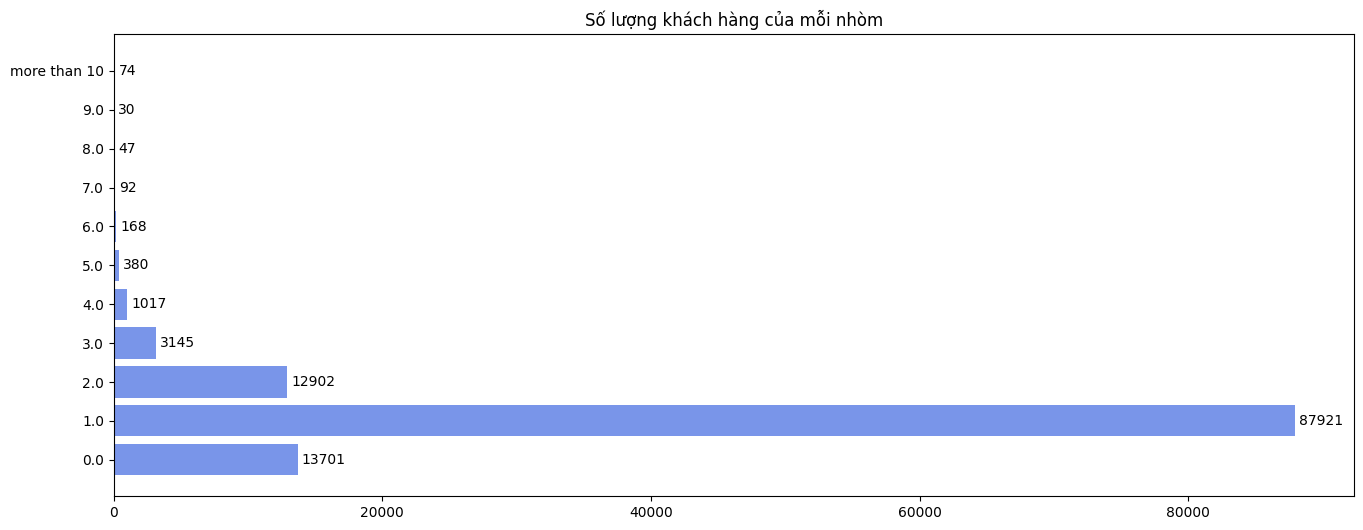

In [ ]:
plt.figure(figsize=(16,6))
cot=plt.barh(df_n_dis['n_order_dis'],df_n_dis['total_cus'],color='royalblue',alpha=0.7)
plt.title('Số lượng khách hàng của mỗi nhòm')
plt.bar_label(cot,padding=3)

đa số khách hàng mua 1 lần rồi k quay lại nữa

In [ ]:
df_customer_value.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119477 entries, 0 to 119476
Data columns (total 13 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   customer_id     119477 non-null  int64  
 1   n_total         119477 non-null  int64  
 2   n_failed        119477 non-null  int64  
 3   n_success       119477 non-null  float64
 4   s_money         119477 non-null  float64
 5   s_discount      119477 non-null  float64
 6   n_date          119477 non-null  float64
 7   n_month         119477 non-null  float64
 8   n_promotion     119477 non-null  float64
 9   success_rate    119477 non-null  float64
 10  promotion_rate  105776 non-null  float64
 11  discount_rate   105776 non-null  float64
 12  n_order_dis     119477 non-null  object 
dtypes: float64(9), int64(3), object(1)
memory usage: 11.9+ MB


In [ ]:
#Nếu họ mua dồn vào 1 lúc =>bất thường
# Nếu họ mua dàn trải => Bình thường
# Lấy ra 20 người mua vé nhiều nhất

In [ ]:
df_customer_value.sort_values(by='n_success',ascending=False).head(20)

,customer_id,n_total,n_failed,n_success,s_money,s_discount,n_date,n_month,n_promotion,success_rate,promotion_rate,discount_rate,n_order_dis
2686,102948,260,0,260.0,1291.25,3.38,148.0,18.0,1.0,1.000000,0.003846,0.002618,more than 10
48948,153588,108,1,107.0,434.59,0.00,77.0,14.0,0.0,0.990741,0.000000,0.000000,more than 10
10604,111644,104,0,104.0,581.70,18.52,85.0,18.0,9.0,1.000000,0.086538,0.031838,more than 10
15783,117362,104,1,103.0,744.86,8.62,79.0,15.0,6.0,0.990385,0.058252,0.011573,more than 10
16687,118349,83,3,80.0,344.56,4.21,62.0,17.0,1.0,0.963855,0.012500,0.012218,more than 10
20907,122962,77,1,76.0,447.00,1.86,45.0,9.0,3.0,0.987013,0.039474,0.004161,more than 10
72718,179471,69,1,68.0,375.91,7.14,51.0,9.0,4.0,0.985507,0.058824,0.018994,more than 10
62432,168132,69,3,66.0,249.03,0.00,59.0,14.0,0.0,0.956522,0.000000,0.000000,more than 10
111563,222641,51,0,51.0,240.84,2.31,41.0,11.0,3.0,1.000000,0.058824,0.009591,more than 10
53097,158089,53,2,51.0,245.14,1.69,40.0,14.0,2.0,0.962264,0.039216,0.006894,more than 10


In [ ]:
list_customer_massive=list(df_customer_value[df_customer_value['n_success']>30]['customer_id'].unique())

In [ ]:
list_customer_massive

[np.int64(102948),
 np.int64(103035),
 np.int64(103347),
 np.int64(108110),
 np.int64(108162),
 np.int64(108729),
 np.int64(111644),
 np.int64(114205),
 np.int64(117140),
 np.int64(117362),
 np.int64(117475),
 np.int64(118349),
 np.int64(122962),
 np.int64(131905),
 np.int64(153124),
 np.int64(153588),
 np.int64(158089),
 np.int64(168132),
 np.int64(179471),
 np.int64(222641),
 np.int64(226527),
 np.int64(226886)]

In [ ]:
df_customer_massive_pivot = (
    df_join_all[
        (df_join_all['customer_id'].isin(list_customer_massive)) &
        (df_join_all['status_id'] == 1)
    ]
    .pivot_table(
        index='year_month',
        columns='customer_id',
        values='ticket_id',
        aggfunc='count'
    )
    .reset_index()
)


In [ ]:
df_customer_massive_pivot

customer_id,year_month,102948,103035,103347,108110,108162,108729,111644,114205,117140,117362,117475,118349,122962,131905,153124,153588,158089,168132,179471,222641,226527,226886
0,2019-01,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-02,NaN,NaN,NaN,NaN,1.0,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2019-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2019-04,NaN,3.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,2.0,NaN,3.0,NaN,NaN,NaN,NaN,NaN
4,2019-05,NaN,2.0,NaN,NaN,4.0,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,2.0,3.0,NaN,7.0,NaN,NaN,NaN,NaN,NaN
5,2019-06,NaN,NaN,NaN,NaN,2.0,NaN,NaN,2.0,1.0,NaN,1.0,NaN,NaN,1.0,7.0,NaN,2.0,NaN,NaN,NaN,NaN,NaN
6,2019-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,3.0,NaN,NaN,NaN,NaN,NaN
7,2019-08,NaN,3.0,NaN,NaN,NaN,NaN,NaN,6.0,NaN,NaN,NaN,NaN,NaN,1.0,7.0,NaN,5.0,NaN,NaN,NaN,NaN,NaN
8,2019-09,NaN,2.0,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,2.0,1.0,NaN,2.0,NaN,NaN,NaN,NaN,NaN
9,2019-10,NaN,4.0,NaN,NaN,NaN,NaN,1.0,3.0,NaN,NaN,NaN,NaN,NaN,1.0,1.0,NaN,7.0,NaN,NaN,NaN,NaN,NaN


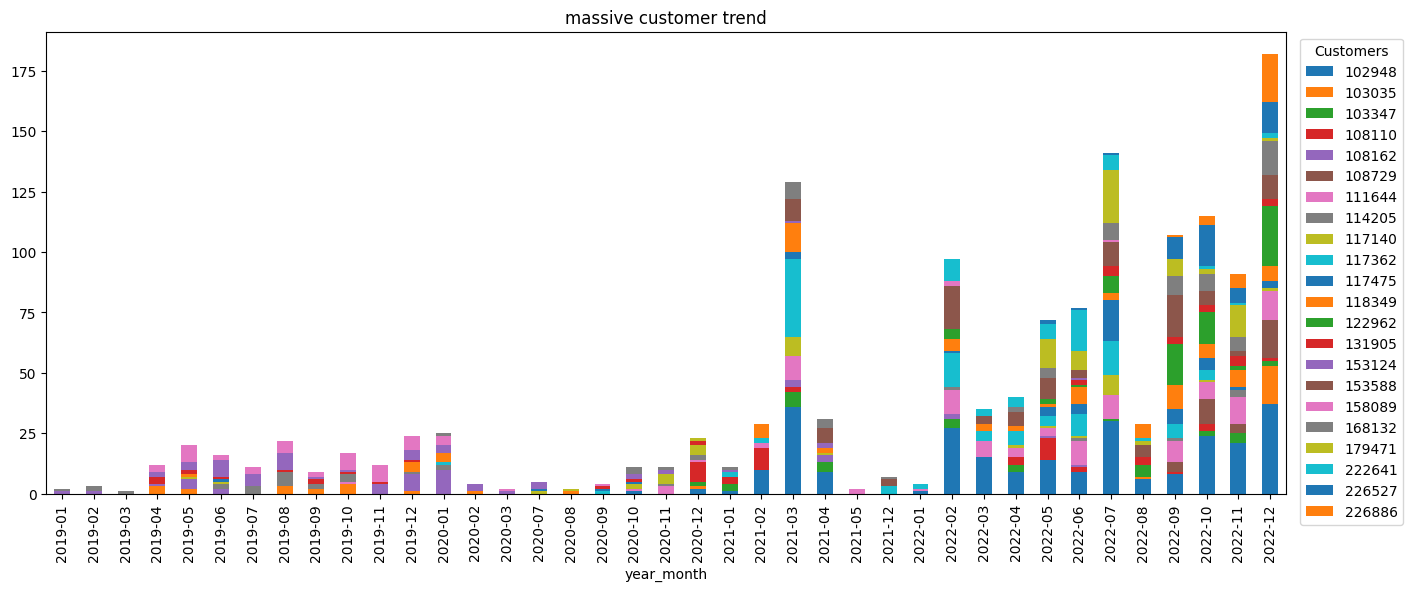

In [ ]:
df_customer_massive_pivot.plot(
    kind='bar',
    x='year_month',
    stacked=True,
    figsize=(16,6),


)
plt.title('massive customer trend')
plt.legend(title='Customers', loc='upper right', bbox_to_anchor=(1.1, 1))



**Note:**
Nhóm khách hàng >30 phân bổ dàn trải -Không có hiện tượng spam vé , mua đi bán lại
-Chưa có gì bất thường

In [ ]:
df_customer_value.head(2)

,customer_id,n_total,n_failed,n_success,s_money,s_discount,n_date,n_month,n_promotion,success_rate,promotion_rate,discount_rate,n_order_dis
0,100001,1,0,1.0,7.42,2.06,1.0,1.0,1.0,1.0,1.000000,0.277628,1.0
1,100003,6,0,6.0,60.95,2.56,6.0,6.0,1.0,1.0,0.166667,0.042002,6.0


In [ ]:
df_customer_value['n_promo_dis']=df_customer_value['n_promotion'].apply(lambda x:'more than 10' if x>=10 else str(x) )

In [ ]:
df_promo_dis=(
    df_customer_value.groupby('n_promo_dis').agg(
    total_cus=('customer_id','count')
).reset_index()
)


In [ ]:
df_promo_dis

,n_promo_dis,total_cus
0,0.0,50498
1,1.0,61334
2,2.0,6264
3,3.0,1042
4,4.0,230
5,5.0,74
6,6.0,19
7,7.0,10
8,8.0,2
9,9.0,2


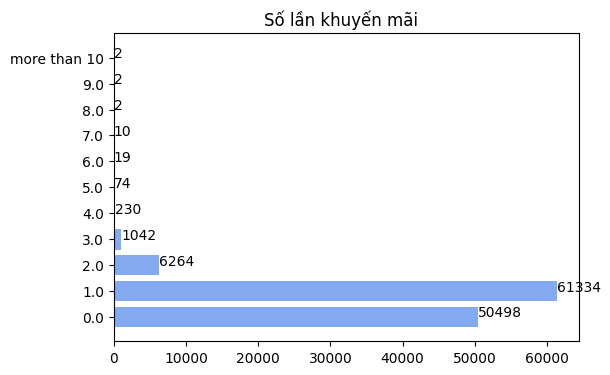

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.barh(
    df_promo_dis['n_promo_dis'],   # nhãn trục y lấy từ cột
    df_promo_dis['total_cus'],     # chiều dài thanh là số khách hàng
    color='cornflowerblue',
    alpha=0.8
)

# hiển thị số lượng khách ngay cuối mỗi thanh
for index, value in enumerate(df_promo_dis['total_cus']):
    plt.text(value, index, str(value))

plt.title('Số lần khuyến mãi  ')
plt.show()



>>- Tầm khoảng 60% khách hàng join vào các chương trình khuyễn mãi
>>- Khoảng 89% khách hàng hưởng khuyến mãi 1 lần duy nhất
>>- TH1 : Khách hàng đến 1 lần rồi thôi or Th2 : Các chương trình promotion chỉ cho 1 người dùng 1 lần , maybe  danh cho những khách hàng mới => làm rõ với teamproduct , team marketing

In [ ]:
# Vậy loại khuyến mãi mà khach hàng đang dùng là gì



In [ ]:
df_join_all.head(2)

,ticket_id,customer_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,campaign_id,movie_name,usergender,dob,campaign_type,description,error_group,model,platform,age_days,age,month,name_day,hour,year_month,os_version,type
0,4f5200dcdcf2396b8d50ff84bf423f32,100009,money in app,13.0,244764a57dbdeb8fe9b164847ad55183,9.90,2.10,7.80,2022-07-08 17:46:36.145,1,83330,Thor: Love And Thunder,Male,1989-02-25,direct discount,Order successful,unknow,"iPhone13,1",mobile,13706,37,7,Friday,17,2022-07,ios,promotion
1,07abbaf28c772692f0367ad992bb3184,100493,bank account,180.0,8fa83cf46284aafd6e5da6c96f7862b5,8.66,1.48,7.18,2022-07-15 20:44:09.952,1,83330,Thor: Love And Thunder,Male,1991-06-09,direct discount,Order successful,unknow,browser,website,12872,35,7,Friday,20,2022-07,browser,promotion


In [ ]:
# Đánh giá loại khuyến mãi khách hàng dùng
df_type_group=(
    df_join_all[(df_join_all['status_id']==1)&(df_join_all['type']=='promotion')]
    .groupby('campaign_type').agg(
        total_tick=('ticket_id','count')
    ).reset_index()

)

In [ ]:
df_type_group

,campaign_type,total_tick
0,direct discount,68449
1,reward point,3150
2,voucher,6924


In [ ]:
#Tinhs tỷ lệ loại khuyến mãi chi tiết cho từng nhóm khách hàng , 1km, 2km,3km...


In [ ]:
df_n_success=(
    df_join_all[(df_join_all['status_id']==1)&(df_join_all['type']=='promotion')]
    .groupby('customer_id').agg(
        total_tick=('ticket_id','count')
    ).reset_index()

)

In [ ]:
df_n_success

,customer_id,total_tick
0,100001,1
1,100003,1
2,100005,1
3,100007,1
4,100009,7
...,...,...
68974,231393,1
68975,231395,1
68976,231397,1
68977,231398,1


In [ ]:
df_n_pivot=(
    df_join_all[(df_join_all['status_id']==1)&(df_join_all['type']=='promotion')]
    .pivot_table(
        index='customer_id',
        columns='campaign_type',
        aggfunc='count',
        values='ticket_id').reset_index()


)

In [ ]:
df_n_pivot

campaign_type,customer_id,direct discount,reward point,voucher
0,100001,NaN,NaN,1.0
1,100003,1.0,NaN,NaN
2,100005,NaN,NaN,1.0
3,100007,1.0,NaN,NaN
4,100009,7.0,NaN,NaN
...,...,...,...,...
68974,231393,NaN,NaN,1.0
68975,231395,1.0,NaN,NaN
68976,231397,NaN,NaN,1.0
68977,231398,NaN,NaN,1.0


In [ ]:
df_n_join=(
    pd.merge(df_n_success,df_n_pivot,how='inner',on='customer_id')
    .groupby('total_tick').agg(
       n_cus=('customer_id','count'),
       n_voucher=('voucher','count'),
       n_d_discount=('direct discount','count'),
       n_r_point=('reward point','count')
    ).reset_index()
)

In [ ]:
df_n_join

,total_tick,n_cus,n_voucher,n_d_discount,n_r_point
0,1,61334,5358,53098,2878
1,2,6264,777,5905,215
2,3,1042,156,982,45
3,4,230,34,216,6
4,5,74,17,71,4
5,6,19,6,19,0
6,7,10,4,9,1
7,8,2,1,2,0
8,9,2,2,2,0
9,10,1,1,1,0


In [ ]:
df_n_join['Total']=df_n_join.iloc[:,2:].sum(axis=1)


In [ ]:
for i in df_n_join.columns[2:5]:
  df_n_join[i+'_ptc']=df_n_join[i]/df_n_join['Total']

In [ ]:
df_n_join

,total_tick,n_cus,n_voucher,n_d_discount,n_r_point,Total,n_voucher_ptc,n_d_discount_ptc,n_r_point_ptc
0,1,61334,5358,53098,2878,61334,0.087358,0.865719,0.046923
1,2,6264,777,5905,215,6897,0.112658,0.856169,0.031173
2,3,1042,156,982,45,1183,0.131868,0.830093,0.038039
3,4,230,34,216,6,256,0.132812,0.843750,0.023438
4,5,74,17,71,4,92,0.184783,0.771739,0.043478
5,6,19,6,19,0,25,0.240000,0.760000,0.000000
6,7,10,4,9,1,14,0.285714,0.642857,0.071429
7,8,2,1,2,0,3,0.333333,0.666667,0.000000
8,9,2,2,2,0,4,0.500000,0.500000,0.000000
9,10,1,1,1,0,2,0.500000,0.500000,0.000000


In [ ]:
format_dict={'Total':'{:.0f}',	'n_voucher_ptc':'{:.0%}',	'n_d_discount_ptc':'{:.0%}',	'n_r_point_ptc':'{:.0%}'}

In [ ]:
# Tô màu ( heat map cho table):
(
    df_n_join
    .drop(columns=['n_voucher',	'n_d_discount',	'n_r_point'])
    .style
    .format(format_dict)
    .background_gradient(subset=['n_voucher_ptc',	'n_d_discount_ptc',	'n_r_point_ptc'],cmap='PuBu')
    .background_gradient(subset=['Total'],cmap='YlGn')
)

,total_tick,n_cus,Total,n_voucher_ptc,n_d_discount_ptc,n_r_point_ptc
0,1,61334,61334,9%,87%,5%
1,2,6264,6897,11%,86%,3%
2,3,1042,1183,13%,83%,4%
3,4,230,256,13%,84%,2%
4,5,74,92,18%,77%,4%
5,6,19,25,24%,76%,0%
6,7,10,14,29%,64%,7%
7,8,2,3,33%,67%,0%
8,9,2,4,50%,50%,0%
9,10,1,2,50%,50%,0%


>**Note:**
>>- Gần 90% Khách hằng chọn tham gia các campaign Direct discount
>>- Đánh giá thêm về tỉ lệ quay lại của khách hàng ->Quay trở lại >->Hiệu quả của MKT

## 3.5 Customer Retension-Cohort Analysis

>>- Đánh giá tỷ lệ giữ chân khách hàng
>>- Tìm ra các yếu tố ảnh hướng đến retention

In [ ]:
from operator import attrgetter
import matplotlib.colors as mcolors
import seaborn as sns


In [ ]:
# Tính toán các thông tin cohort(firt _month, current month , subsequence month)

In [ ]:
df_join_all.head(2)

,ticket_id,customer_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,campaign_id,movie_name,usergender,dob,campaign_type,description,error_group,model,platform,age_days,age,month,name_day,hour,year_month,os_version,type
0,4f5200dcdcf2396b8d50ff84bf423f32,100009,money in app,13.0,244764a57dbdeb8fe9b164847ad55183,9.90,2.10,7.80,2022-07-08 17:46:36.145,1,83330,Thor: Love And Thunder,Male,1989-02-25,direct discount,Order successful,unknow,"iPhone13,1",mobile,13706,37,7,Friday,17,2022-07,ios,promotion
1,07abbaf28c772692f0367ad992bb3184,100493,bank account,180.0,8fa83cf46284aafd6e5da6c96f7862b5,8.66,1.48,7.18,2022-07-15 20:44:09.952,1,83330,Thor: Love And Thunder,Male,1991-06-09,direct discount,Order successful,unknow,browser,website,12872,35,7,Friday,20,2022-07,browser,promotion


Tinh năm 2019






In [ ]:
df_selected_time=df_join_all[(df_join_all['time']<'2022-01-01')&(df_join_all['status_id']==1)]
# Tinhs thang đầu tiên tham gia
df_selected_time['first_month']=df_selected_time.groupby('customer_id')['time'].transform('min').dt.to_period('M')
#Tính tháng hiện tại
df_selected_time['current_month']=df_selected_time['time'].dt.to_period('M')
# Khoảng cách của những đơn hàng hiện tại so với giao dịch đầu tiên
df_selected_time['subsequence_month']=(df_selected_time['current_month']-df_selected_time['first_month']).apply(attrgetter('n'))


/tmp/ipykernel_3525/3091389511.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected_time['first_month']=df_selected_time.groupby('customer_id')['time'].transform('min').dt.to_period('M')
/tmp/ipykernel_3525/3091389511.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected_time['current_month']=df_selected_time['time'].dt.to_period('M')
/tmp/ipykernel_3525/3091389511.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexe

In [ ]:
#Bước 2 : groupby by cohort
df_cohor = (
    df_selected_time
    .groupby(['first_month', 'current_month', 'subsequence_month'])
    .agg(n_customers = ('customer_id', 'nunique'))
    .reset_index(drop=False)
)

In [ ]:
#Chuyển sang kiểu string
df_cohor['first_month']=df_cohor['first_month'].astype(str)
df_cohor['current_month']=df_cohor['current_month'].astype(str)

In [ ]:
#pivot kết quả
df_cohor_pivot=(
    df_cohor
    .pivot_table(
        index='first_month',#index là cột giữ nguyên
        columns='subsequence_month',
        values='n_customers'

    )
)


In [ ]:
df_cohor_pivot

subsequence_month,0,1,2,3,4,5,6,7,8,9,10,11
first_month,,,,,,,,,,,,
2022-01,474.0,31.0,24.0,25.0,30.0,23.0,28.0,13.0,20.0,13.0,20.0,25.0
2022-02,3212.0,94.0,99.0,160.0,120.0,161.0,77.0,90.0,117.0,68.0,81.0,NaN
2022-03,3675.0,117.0,157.0,111.0,188.0,83.0,106.0,115.0,110.0,90.0,NaN,NaN
2022-04,4240.0,218.0,126.0,204.0,84.0,109.0,126.0,127.0,99.0,NaN,NaN,NaN
2022-05,10365.0,324.0,488.0,143.0,207.0,263.0,253.0,214.0,NaN,NaN,NaN,NaN
2022-06,6511.0,307.0,139.0,166.0,157.0,141.0,143.0,NaN,NaN,NaN,NaN,NaN
2022-07,13630.0,252.0,303.0,344.0,295.0,270.0,NaN,NaN,NaN,NaN,NaN,NaN
2022-08,4069.0,139.0,135.0,110.0,103.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-09,5843.0,194.0,155.0,143.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#Chuyển sang phần trăm
cohort_size=df_cohor_pivot.iloc[:,0]# chọn rất cả các dòng trong cột đầu tiền
retention_matrix=df_cohor_pivot.divide(cohort_size,axis=0)# chia theo từng hàng

In [ ]:
retention_matrix

subsequence_month,0,1,2,3,4,5,6,7,8,9,10,11
first_month,,,,,,,,,,,,
2022-01,1.0,0.065401,0.050633,0.052743,0.063291,0.048523,0.059072,0.027426,0.042194,0.027426,0.042194,0.052743
2022-02,1.0,0.029265,0.030822,0.049813,0.037360,0.050125,0.023973,0.028020,0.036426,0.021171,0.025218,NaN
2022-03,1.0,0.031837,0.042721,0.030204,0.051156,0.022585,0.028844,0.031293,0.029932,0.024490,NaN,NaN
2022-04,1.0,0.051415,0.029717,0.048113,0.019811,0.025708,0.029717,0.029953,0.023349,NaN,NaN,NaN
2022-05,1.0,0.031259,0.047082,0.013796,0.019971,0.025374,0.024409,0.020646,NaN,NaN,NaN,NaN
2022-06,1.0,0.047151,0.021348,0.025495,0.024113,0.021656,0.021963,NaN,NaN,NaN,NaN,NaN
2022-07,1.0,0.018489,0.022230,0.025238,0.021643,0.019809,NaN,NaN,NaN,NaN,NaN,NaN
2022-08,1.0,0.034161,0.033178,0.027034,0.025313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-09,1.0,0.033202,0.026527,0.024474,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


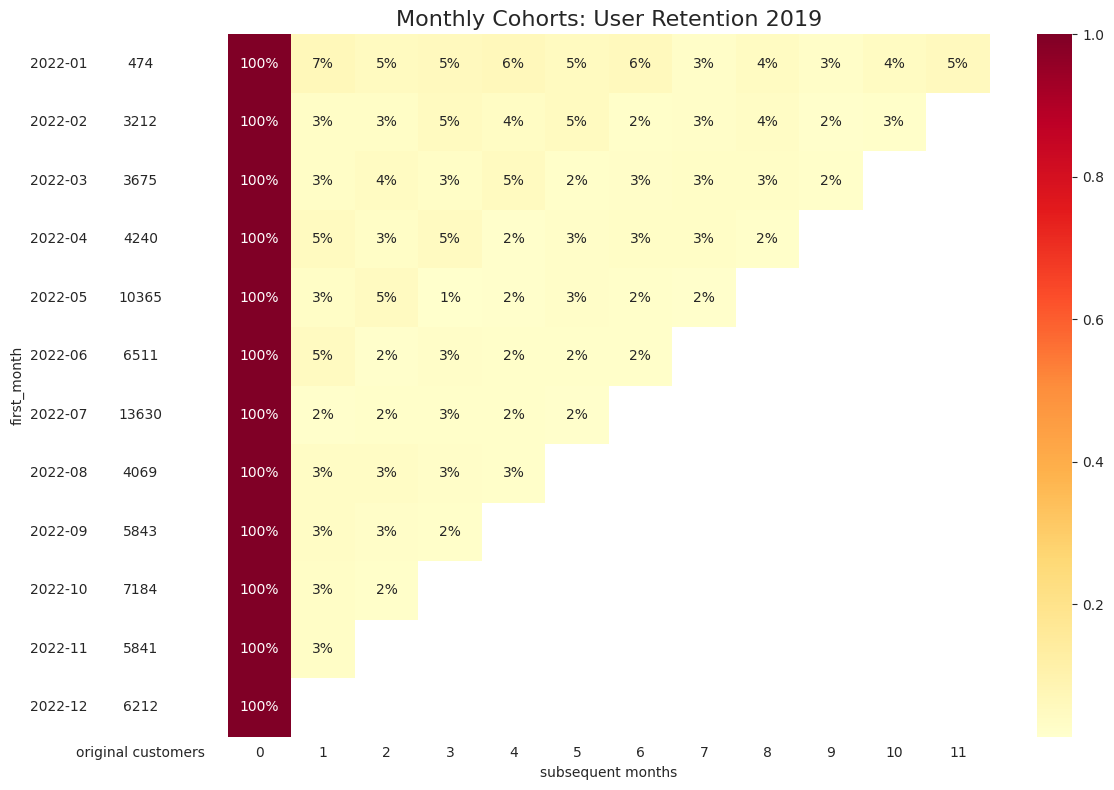

In [ ]:
# Vẽ biểu đồ cohort
with sns.axes_style("white"):
    fig, ax = plt.subplots(1, 2, figsize=(12, 8), sharey=True, gridspec_kw={'width_ratios': [1, 11]})

    # retention matrix
    sns.heatmap(retention_matrix,
                mask=retention_matrix.isnull(),# đoạn nào null sẽ k cho nó hiển thị ra
                annot=True,
                fmt='.0%',
                cmap='YlOrRd',
                ax=ax[1])
    ax[1].set_title('Monthly Cohorts: User Retention 2019', fontsize=16)
    ax[1].set(xlabel='subsequent months',
              ylabel='')

    # cohort size
    cohort_size_df = pd.DataFrame(cohort_size).rename(columns={0: 'original customers'})
    white_cmap = mcolors.ListedColormap(['white'])
    sns.heatmap(cohort_size_df,
                annot=True,
                cbar=False,
                fmt='g',
                cmap=white_cmap,
                alpha=0.5,
                ax=ax[0])

    fig.tight_layout()

Tính năm 2022

In [ ]:
df_selected_time=df_join_all[(df_join_all['time']>'2022-01-01')&(df_join_all['status_id']==1)]
# Tinhs thang đầu tiên tham gia
df_selected_time['first_month']=df_selected_time.groupby('customer_id')['time'].transform('min').dt.to_period('M')
#Tính tháng hiện tại
df_selected_time['current_month']=df_selected_time['time'].dt.to_period('M')
# Khoảng cách của những đơn hàng hiện tại so với giao dịch đầu tiên
df_selected_time['subsequence_month']=(df_selected_time['current_month']-df_selected_time['first_month']).apply(attrgetter('n'))


/tmp/ipykernel_3525/2362534284.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected_time['first_month']=df_selected_time.groupby('customer_id')['time'].transform('min').dt.to_period('M')
/tmp/ipykernel_3525/2362534284.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected_time['current_month']=df_selected_time['time'].dt.to_period('M')
/tmp/ipykernel_3525/2362534284.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexe

In [ ]:
#Bước 2 : groupby by cohort
df_cohor = (
    df_selected_time
    .groupby(['first_month', 'current_month', 'subsequence_month'])
    .agg(n_customers = ('customer_id', 'nunique'))
    .reset_index(drop=False)
)

In [ ]:
#Chuyển sang kiểu string
df_cohor['first_month']=df_cohor['first_month'].astype(str)
df_cohor['current_month']=df_cohor['current_month'].astype(str)

In [ ]:
#pivot kết quả
df_cohor_pivot=(
    df_cohor
    .pivot_table(
        index='first_month',#index là cột giữ nguyên
        columns='subsequence_month',
        values='n_customers'

    )
)


In [ ]:
#Chuyển sang phần trăm
cohort_size=df_cohor_pivot.iloc[:,0]# chọn rất cả các dòng trong cột đầu tiền
retention_matrix=df_cohor_pivot.divide(cohort_size,axis=0)# chia theo từng hàng

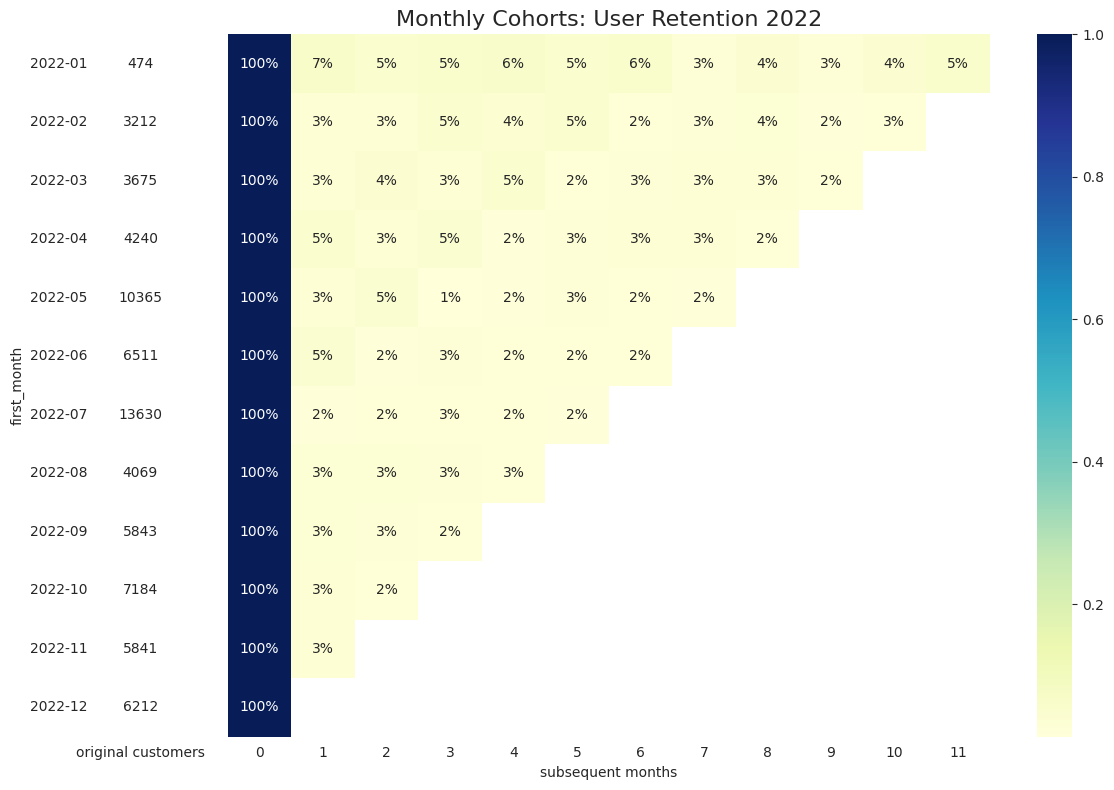

In [ ]:
# Vẽ biểu đồ cohort
with sns.axes_style("white"):
    fig, ax = plt.subplots(1, 2, figsize=(12, 8), sharey=True, gridspec_kw={'width_ratios': [1, 11]})

    # retention matrix
    sns.heatmap(retention_matrix,
                mask=retention_matrix.isnull(),# đoạn nào null sẽ k cho nó hiển thị ra
                annot=True,
                fmt='.0%',
                cmap='YlGnBu',
                ax=ax[1])
    ax[1].set_title('Monthly Cohorts: User Retention 2022', fontsize=16)
    ax[1].set(xlabel='subsequent months',
              ylabel='')

    # cohort size
    cohort_size_df = pd.DataFrame(cohort_size).rename(columns={0: 'original customers'})
    white_cmap = mcolors.ListedColormap(['white'])
    sns.heatmap(cohort_size_df,
                annot=True,
                cbar=False,
                fmt='g',
                cmap=white_cmap,
                alpha=0.5,
                ax=ax[0])

    fig.tight_layout()

>**Note**
>>- Retension namư 2019 và năm 2022 chưa có nhiều sự thay đổi , do thị trường phim mới hồi phục nên chưa được cải thiện
>>- Tại sao retention lại thấp trong khi 70% khách hàng hưởng khuyến mãi ?

So sánh retention của khách hàng hưởng khuyến mãi và khách hàng không hưởng khuyến mãi có khác biệt gì hay k ?


In [ ]:
df_pie_promo=(
    df_join_all[(df_join_all['status_id']==1) & (df_join_all['time']>'2022-01-01')]
    .groupby('type').agg(
        total_cus=('customer_id','nunique')

    ).reset_index().sort_values(by='total_cus',ascending=True)
)

In [ ]:
df_pie_promo

,type,total_cus
0,none-promotion,27672
1,promotion,47507


Text(0.5, 1.0, 'Tỷ lệ phần trăm theo type')

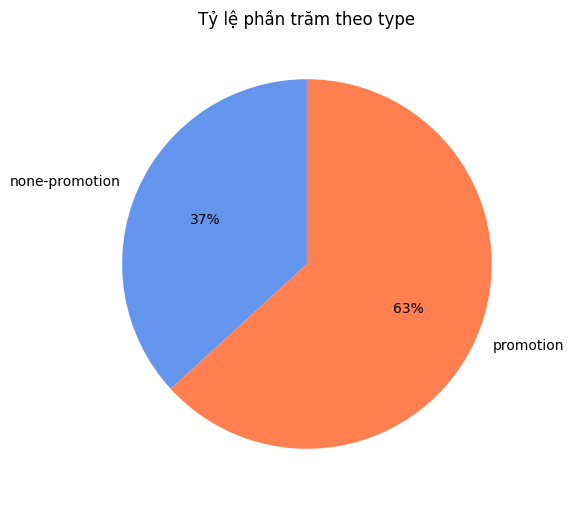

In [ ]:
# vẽ biểu đồ pie chart
plt.figure(figsize=(6,6))
plt.pie(
    df_pie_promo['total_cus'],
    labels=df_pie_promo['type'],
    autopct='%1.0f%%',
    startangle=90,
    colors=['cornflowerblue','coral']

    # colors=df_pie_promo['type'].replace({'promotion':'royalblue','none-promotion':'orangered'}),







    )
plt.title('Tỷ lệ phần trăm theo type')



In [ ]:
# Phân biệt nhóm hưởng promotion và nhóm không hưởng : dựa vào vé đầu tiên (first order)


In [ ]:
# Đánh số thứ tự cho từng vé của từng người



In [ ]:
df_data_check=(df_join_all[(df_join_all['status_id']==1)&(df_join_all['time']>'2022-01-01')][['customer_id','ticket_id','time','type']]
.sort_values(by=['customer_id','time'])
)

In [ ]:
df_data_check.head(10)

,customer_id,ticket_id,time,type
66484,100003,34c4764b4afa000af4c33a525f20eace,2022-05-22 12:52:12.105,none-promotion
10001,100004,1c4aa39842bfc83dbb5856c25a33d9cb,2022-12-20 06:26:21.373,none-promotion
108794,100007,5565ba5e22475c7cce298a2bea470428,2022-03-21 17:57:18.460,promotion
0,100009,4f5200dcdcf2396b8d50ff84bf423f32,2022-07-08 17:46:36.145,promotion
5585,100009,0724203b5146b0ebae6e3678ed7eccde,2022-12-24 09:32:45.477,promotion
69405,100013,f95441286dcfa045f61a5760662616e1,2022-05-05 12:22:44.587,none-promotion
140483,100018,1e40fb2d0f6264ed3127f79b1a12c9c9,2022-09-07 21:13:17.896,none-promotion
90595,100018,9a959ff1649950949ff2c0aff4b62205,2022-11-19 16:25:43.981,promotion
35270,100020,af02fc96a6703af7d93162d9f8c61dba,2022-05-28 19:09:37.936,promotion
16649,100023,5ed44ff62214268ffcb14d4ea78b04d8,2022-05-16 08:45:42.397,promotion


In [ ]:
#Đánh số thứ tự
df_data_check['row_number']=df_data_check.groupby('customer_id').cumcount()+1
# vi du khách hàng 109 có 2 đơn hàng , số 1 và 2

In [ ]:
# lọc ra những dòng có type là promotion

df_data_check[(df_data_check['type']=='promotion')&(df_data_check['row_number']==1)]['customer_id'].nunique()

46189

In [ ]:
# co 97 % khách hàng đến từ promotion trong nhóm khách hàng có tham gia promo( tức trong số khách hàng tham gia promo thì có tới 97% là khách hàng mới )
#->retention là bao bao nhiêu ?


In [ ]:
df_first_promo_list=df_data_check[(df_data_check['type']=='promotion')&(df_data_check['row_number']==1)]['customer_id']
df_first_promo_list.drop_duplicates(inplace=True)
df_first_promo_check=pd.merge(df_data_check,df_first_promo_list,how='inner',on='customer_id')


/tmp/ipykernel_3525/698261981.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_first_promo_list.drop_duplicates(inplace=True)


In [ ]:
df_first_promo_check

,customer_id,ticket_id,time,type,row_number
0,100007,5565ba5e22475c7cce298a2bea470428,2022-03-21 17:57:18.460,promotion,1
1,100009,4f5200dcdcf2396b8d50ff84bf423f32,2022-07-08 17:46:36.145,promotion,1
2,100009,0724203b5146b0ebae6e3678ed7eccde,2022-12-24 09:32:45.477,promotion,2
3,100020,af02fc96a6703af7d93162d9f8c61dba,2022-05-28 19:09:37.936,promotion,1
4,100023,5ed44ff62214268ffcb14d4ea78b04d8,2022-05-16 08:45:42.397,promotion,1
...,...,...,...,...,...
53939,231393,92d8ee40d9c67d6735032d8b6967150a,2022-12-30 22:23:37.942,promotion,1
53940,231395,5ff0423850f31354fc5825f7f1c1ec3e,2022-12-30 21:49:52.181,promotion,1
53941,231397,65156cae3a601e35c266d6160b0600b4,2022-12-30 23:12:45.231,promotion,1
53942,231398,53cbd4a121957face9e948c3c794384c,2022-12-31 12:24:25.127,promotion,1


In [ ]:
# Timf ra số ngườiquay trở lại của nhóm khách hàng hưởng khuyến mãi
(
    df_first_promo_check[df_first_promo_check['row_number']==2]['customer_id'].nunique()
/
df_first_promo_check['customer_id'].nunique()
)

0.1308969668102795

In [ ]:
# Có 13% khách hàng quay lại kể từ lần đầu mua hàng ( tỷ lệ chuyể đồi , giữ chân =13%)
# Nhóm khách hàng k hưởng khuyến mãi có khác biệt k ?


Tính retention của nhóm không hưởng khuyến mãi

In [ ]:
df_first_non_promo_list=df_data_check[(df_data_check['type']=='none-promotion')&(df_data_check['row_number']==1)]['customer_id']
df_first_non_promo_list.drop_duplicates(inplace=True)
df_first_non_promo_check=pd.merge(df_data_check,df_first_non_promo_list,how='inner',on='customer_id')

(
    df_first_non_promo_check[df_first_non_promo_check['row_number']==2]['customer_id'].nunique()
/
df_first_non_promo_check['customer_id'].nunique()
)


/tmp/ipykernel_3525/2705030330.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_first_non_promo_list.drop_duplicates(inplace=True)


0.12195316551641601

In [ ]:
# Nhóm khách hàng k hưởng promotion có tỷ lệ quay lại là 12%

**Note:**
>>- 97% promotion năm 2022 là dành cho khách hàng mới , tuy nhiên
>>- Chỉ có 13% khách hàng quay trở lại trong khi tỷ lệ của nhóm khách hàng k hưởng khuyến mãi là 12%
>>- --> Công ty rất chú trọng trong việc thu hút khách hàng mới nhưng chưa đẩy mạnh việc giữ chân khách hàng

**3.6 Tỷ lệ  Thanh toán thành công **

```
# Overview
```



**Overview**

In [ ]:
# Kiểm tra success_rate toàn thời gian
def calculate_n_success(x):
  return (x==1).sum()

def_sr=(
    df_join_all
    .groupby('year_month')
    .agg(
        n_ords=('ticket_id','count'),# total ticket
        n_success=('status_id',calculate_n_success)# success ticket


    ).reset_index()

)
def_sr['success_rate'] = (def_sr['n_success'] / def_sr['n_ords']) * 100

In [ ]:
def_sr.head(5)

,year_month,n_ords,n_success,success_rate
0,2019-01,2019,1359,67.310550
1,2019-02,1626,1427,87.761378
2,2019-03,1004,866,86.254980
3,2019-04,4069,3190,78.397641
4,2019-05,4430,3617,81.647856


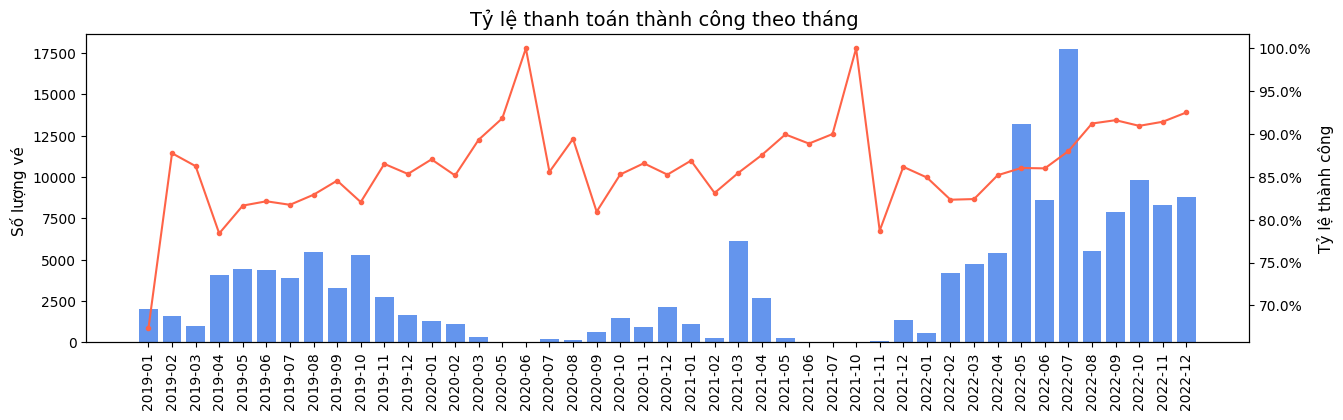

In [ ]:
# Vẽ biểu đồ cột và đường
from matplotlib.ticker import PercentFormatter
fig ,ax1=plt.subplots(figsize=(15,4))
ax1.bar(def_sr['year_month'],def_sr['n_ords'],color='cornflowerblue')
plt.ylabel('Số lượng vé ',fontsize=11)
plt.xticks(rotation='vertical')

ax2=ax1.twinx()# LẤY TRỤC Y ĐẶT BÊN TAY PHẢI
ax2.plot(def_sr['year_month'],def_sr['success_rate'],color='tomato',marker='o',ms=3)
ax2.yaxis.set_major_formatter(PercentFormatter())
plt.ylabel('Tỷ lệ thành công',fontsize=11)
plt.title('Tỷ lệ thanh toán thành công theo tháng ',fontsize=14)
plt.show()

In [ ]:
df_join_all.head(2)

,ticket_id,customer_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,campaign_id,movie_name,usergender,dob,campaign_type,description,error_group,model,platform,age_days,age,month,name_day,hour,year_month,os_version,type
0,4f5200dcdcf2396b8d50ff84bf423f32,100009,money in app,13.0,244764a57dbdeb8fe9b164847ad55183,9.90,2.10,7.80,2022-07-08 17:46:36.145,1,83330,Thor: Love And Thunder,Male,1989-02-25,direct discount,Order successful,unknow,"iPhone13,1",mobile,13706,37,7,Friday,17,2022-07,ios,promotion
1,07abbaf28c772692f0367ad992bb3184,100493,bank account,180.0,8fa83cf46284aafd6e5da6c96f7862b5,8.66,1.48,7.18,2022-07-15 20:44:09.952,1,83330,Thor: Love And Thunder,Male,1991-06-09,direct discount,Order successful,unknow,browser,website,12872,35,7,Friday,20,2022-07,browser,promotion


In [ ]:
df_error_group=(
    df_join_all[df_join_all['status_id']!=1]
    .groupby(['year_month','error_group'])
    .agg(
        n_ords=('ticket_id','count')

    ).reset_index().sort_values(by='year_month',ascending=True)
)

In [ ]:
df_error_group['error_group'].unique()

array(['customer', 'external', 'internal'], dtype=object)

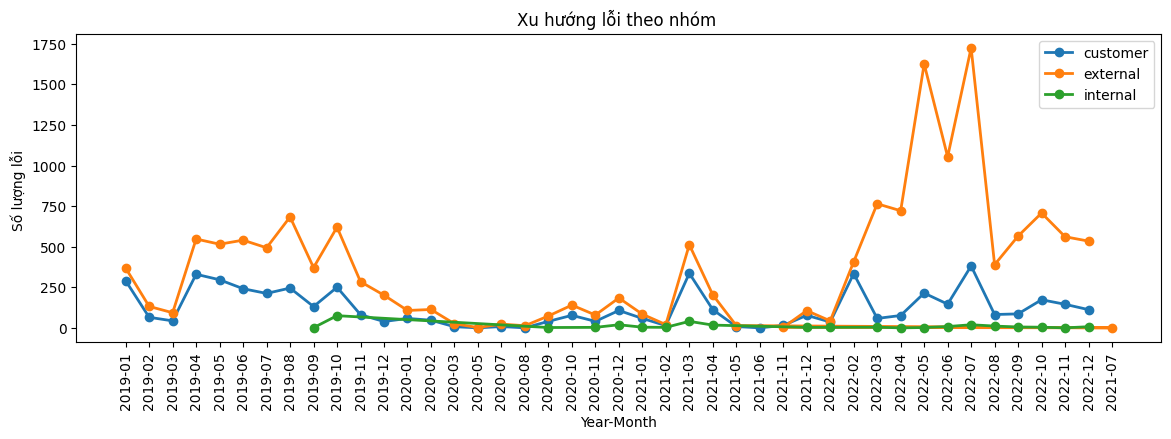

In [ ]:
import matplotlib.pyplot as plt

# lọc từng nhóm lỗi
df_customer = df_error_group[df_error_group['error_group'] == 'customer']
df_external = df_error_group[df_error_group['error_group'] == 'external']
df_internal = df_error_group[df_error_group['error_group'] == 'internal']

# vẽ biểu đồ đường
plt.figure(figsize=(14, 4))
plt.plot(df_customer['year_month'], df_customer['n_ords'], label='customer',marker='o',linewidth=2)
plt.plot(df_external['year_month'], df_external['n_ords'], label='external',marker='o',linewidth=2)
plt.plot(df_internal['year_month'], df_internal['n_ords'], label='internal',marker='o',linewidth=2)

plt.xlabel('Year-Month')
plt.ylabel('Số lượng lỗi ')
plt.title('Xu hướng lỗi theo nhóm ')
plt.legend()
plt.xticks(rotation='vertical')
plt.show()



In [ ]:
 # Tại sao trong năm 2022 nhóm lỗi external lại tăng đột biến như vậy

In [ ]:
#Phân bố mã lỗi
df_error=(
    df_join_all[df_join_all['status_id']!=1]
    .groupby(['year_month','description'])
    .agg(
        n_ords=('ticket_id','count')

    ).reset_index().sort_values(by='year_month',ascending=True)

)

In [ ]:
df_error['description'].unique()

array(['Insufficient funds in customer account. Please add more funds and try the transaction again.',
       'No response from your bank',
       'Password locked due to multiple incorrect attempts. Choose Forgot Password to unlock.',
       'Payment failed from bank', 'Payment overdue',
       'Transaction temporarily limited',
       'Need verify your account to continue'], dtype=object)

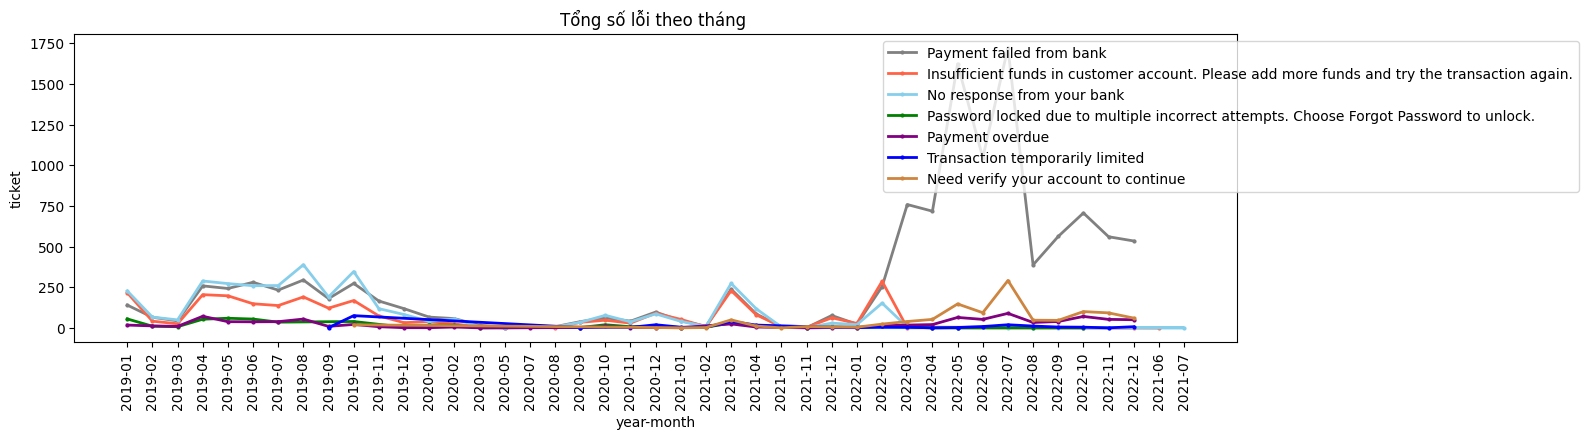

In [ ]:
# Phân bổ nhóm lỗi:
error_color_pairs = [
    ('Payment failed from bank', 'gray'),
    ('Insufficient funds in customer account. Please add more funds and try the transaction again.', 'tomato'),
    ('No response from your bank', 'skyblue'),
    ('Password locked due to multiple incorrect attempts. Choose Forgot Password to unlock.', 'green'),
    ('Payment overdue', 'purple'),
    ('Transaction temporarily limited', 'blue'),
    ('Need verify your account to continue', 'peru')
]

plt.figure(figsize=(15, 4))
for error, color in error_color_pairs:
    df_err_line = df_error[df_error['description'] == error]
    plt.plot(
        df_err_line['year_month'],
        df_err_line['n_ords'],
        label=error,
        marker='o',
        color=color,
        linewidth=2,
        markersize=2
    )

plt.title('Tổng số lỗi theo tháng ')
plt.xlabel('year-month')
plt.ylabel('ticket')
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1))
plt.xticks(rotation=90)
plt.show()
